#  Data Segmentation & Local EDA 

### Notebook outline

The notebook provides code for the following steps in the preprocessing pipeline: 

**1. Initial quality check**
- Check datetime index alignment 
- Check timerange 

**2. Comparison of resampled dataframes**
- Compare 10 min resampled dataframes to determine whether alignment of timestamps during preprocessing impacts statistical distribution
- Compare resampled dataset distribution with original dataset

**3. Identifying continuous subsegments of data for feature engineering & modeling**
- Group continuous segments of data using a 1-day duration threshold to remove largest gaps in the dataset 
- Plot each segment to visualize data distribution / emissions data 

This will act as the basis for selecting segments that will be used for feature engineering. 

**4. Local EDA of selected subsegments**
- Identify size of data gaps < 1 day to assess best method for interpolation 
- Additional EDA of selected segments to understand extreme value distribution, key variables and seasonal distribution.

**5. Interpolation of missing data**
- Interpolate data using the selected method

**Note:** 
The two datasets that are compared in this notebook are based on the data_preprocessing notebook, which includes: 

- df_10T: dataset resampled at a 10-min frequency, timestamps are not aligned before resampling, 

- df_aligned_10T: timestamps are aligned before resampling by shifting all timestamps to odd minutes and flooring them to a single value (see preprocessing notebook). 



## 1. Initial Quality Check 

In [5]:
#Import relevant libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, ks_2samp

import warnings
warnings.filterwarnings('ignore')

#Display settings 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)

#Plot settings
sns.set_theme(
    style="darkgrid",
    context="notebook",
    font_scale=1.1
)

plt.rcParams['figure.dpi'] = 100  # Higher resolution figures
plt.rcParams['savefig.dpi'] = 300  # High quality when saving
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 13

In [6]:
#Upload csv files 

#10-min resampled
df_10T = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_10T.csv", index_col=0, parse_dates=True)

#10-min resampled (aligned timestamps)
df_aligned_10T = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_aligned_10T.csv", index_col=0, parse_dates=True)

#Upload orginal csv file for comparison
df_t1 = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_t1_cleaned.csv", index_col=0, parse_dates=True)

In [9]:
#Check index type
print("Index type of df_10T:", type(df_10T.index))
print("Index type of df_aligned_10T:", type(df_aligned_10T.index))
print("Index type of df_t1:", type(df_t1.index))

Index type of df_10T: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index type of df_aligned_10T: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index type of df_t1: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [10]:
#Ensure chronological order of dataframes
df_10T.sort_index(inplace=True)
df_aligned_10T.sort_index(inplace=True)
df_t1.sort_index(inplace=True)

In [11]:
#Check shape of dataframes
print("Shape of df_10T:", df_10T.shape)
print("Shape of df_aligned_10T:", df_aligned_10T.shape)
print("Shape of df_t1 (original sampling frequency):", df_t1.shape)

Shape of df_10T: (105264, 34)
Shape of df_aligned_10T: (105264, 34)
Shape of df_t1 (original sampling frequency): (798466, 34)


In [12]:
#Check time range of dataframes to ensure they cover the same period
print("Time range of df_10T:", df_10T.index.min(), "to", df_10T.index.max())
print("Time range of df_aligned_10T:", df_aligned_10T.index.min(), "to", df_aligned_10T.index.max())
print("Time range of df_t1:", df_t1.index.min(), "to", df_t1.index.max())

Time range of df_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_aligned_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_t1: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00


OK - the time range of the raw dataset is Time range: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00. 

In [13]:
print("10-min resampled dataset:")
display(df_10T.head(5))
print()
print("10-min resampled (aligned) dataset:")
display(df_aligned_10T.head(5))
print()
print("Original dataset:")
display(df_t1.head(5))


10-min resampled dataset:


,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,t1_po4,inflow,t1_phase,phasecode,inlet_tank,outlet_tank,storm_mode,total_airflow_q,t1_valve_pct_q,t1_n2o_q,t1_nh4_q,t1_no3_q,t1_do_q,t1_do_sp_q,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.124573,NaN,1.511840,NaN,0.275189,NaN,2.0,1222.0,1.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.101837,NaN,1.496870,NaN,0.277781,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.292950,NaN,1.514961,NaN,0.319097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.296754,NaN,1.481867,NaN,0.353097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.289009,NaN,1.518550,NaN,0.363993,NaN,2.0,2122.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0



10-min resampled (aligned) dataset:


,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,t1_po4,inflow,t1_phase,phasecode,inlet_tank,outlet_tank,storm_mode,total_airflow_q,t1_valve_pct_q,t1_n2o_q,t1_nh4_q,t1_no3_q,t1_do_q,t1_do_sp_q,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.103247,NaN,1.511840,NaN,0.275189,NaN,2.0,1222.0,1.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.141629,NaN,1.496870,NaN,0.277781,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.324748,NaN,1.514961,NaN,0.319097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.266913,NaN,1.481867,NaN,0.353097,NaN,2.0,2121.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.306728,NaN,1.518550,NaN,0.363993,NaN,2.0,2122.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0



Original dataset:


,total_airflow,total_airflow_q,t1_valve_pct,t1_valve_pct_q,t1_n2o,t1_n2o_q,t1_nh4,t1_nh4_q,t1_no3,t1_no3_q,t1_do,t1_do_q,t1_do_sp,t1_do_sp_q,t1_phase,t1_phase_q,t1_airflow,t1_airflow_q,t1_ss,t1_ss_q,t1_temp,t1_temp_q,phasecode,phasecode_q,inlet_tank,inlet_tank_q,outlet_tank,outlet_tank_q,t1_po4,t1_po4_q,inflow,inflow_q,storm_mode,storm_mode_q
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:01:00+00:00,26829.375000,1.0,NaN,NaN,0.723958,0.0,1.670585,0.0,0.413642,0.0,0.094763,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.525374,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:02:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.238239,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:03:00+00:00,29626.341797,1.0,NaN,NaN,0.721644,0.0,1.531775,0.0,0.413642,0.0,0.115741,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.536805,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:04:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.154271,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:05:00+00:00,28605.208984,1.0,NaN,NaN,0.680556,0.0,1.440835,0.0,0.395636,0.0,0.366030,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.509847,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


## 2. Comparison of resampled datasets 
 
Comparison of df_10T and df_aligned_10T to determine whether aligning timestamps during preprocessing impacts the statistical distribution of the data

### 2.1 - Check timestamp alignment 

In [14]:
#Check that indexes are identical for df_10T and df_aligned_10T
df_10T.index.equals(df_aligned_10T.index)

True

In [15]:
#Define function to check timestamp alignment between two dataframes and report differences
def check_timestamp_alignment(df1, df2, name1="DF1", name2="DF2"):
    
    #Extract indexes
    idx1 = df1.index
    idx2 = df2.index

    #Print number of rows in each dataframe
    print(f"{name1} rows: {len(idx1)}")
    print(f"{name2} rows: {len(idx2)}")

    #If indexes are identical, print success message and return True
    if idx1.equals(idx2):
        print("✔ Indexes are identical.")
        return True

    #If indexes are not identical, print failure message and report differences
    print("✘ Indexes are NOT identical.\n")

    #if indexes are not identical, identify timestamps only in df1 and df2
    only_in_df1 = idx1.difference(idx2)
    only_in_df2 = idx2.difference(idx1)

    #Print the number of timestamps only in each dataframe
    print(f"Timestamps only in {name1}: {len(only_in_df1)}")
    print(f"Timestamps only in {name2}: {len(only_in_df2)}")

    #print examples of timestamps only in each dataframe (up to 5 examples)
    if len(only_in_df1) > 0:
        print(f"Example from {name1} only:", only_in_df1[:5])

    if len(only_in_df2) > 0:
        print(f"Example from {name2} only:", only_in_df2[:5])

    return False

In [16]:
#Check timestamp alignment between df_10T and df_aligned_10T
check_timestamp_alignment(
    df_10T,
    df_aligned_10T,
    name1="Standard 10T",
    name2="Aligned 10T"
)

Standard 10T rows: 105264
Aligned 10T rows: 105264
✔ Indexes are identical.


True

### 2.2 - Compare descriptive statistics & distributions of df_10T and df_aligned_10T

In [17]:
#Define key features for comparison of the two resampled dataframes (only nummerical features considered)
cols_analysis = ['inflow', 't1_airflow', 't1_n2o', 't1_nh4','t1_no3', 't1_do', 't1_temp', 't1_po4',
             't1_ss', 't1_valve_pct']

In [18]:
#Define function to compare descriptive statistics and distributions of two dataframes for specified columns

def compare_two_datasets_table(df1, df2, cols=None, name1="DF1", name2="DF2"):

    #Detect shared numeric columns if not specified
    if cols is None:
        num1 = df1.select_dtypes(include="number").columns
        num2 = df2.select_dtypes(include="number").columns
        cols = list(set(num1).intersection(num2))

    results = []

    #Loop through each column and drop missing values
    for col in cols:
        s1 = df1[col].dropna()
        s2 = df2[col].dropna()

        #Skip columns that don't have valid values
        if len(s1) == 0 or len(s2) == 0:
            continue

        #Calculate mean and standard deviation
        mean1, mean2 = s1.mean(), s2.mean()
        std1, std2 = s1.std(), s2.std()

        #Store resulsts in a dictionary for each column and append to list
        results.append({
            "variable": col,

            f"rows_{name1}": len(df1),
            f"rows_{name2}": len(df2),

            f"mean_{name1}": mean1,
            f"mean_{name2}": mean2,
            "mean_diff": mean2 - mean1,

            f"std_{name1}": std1,
            f"std_{name2}": std2,
            "std_ratio": std2 / std1 if std1 != 0 else np.nan,

            f"median_{name1}": s1.median(),
            f"median_{name2}": s2.median(),

            f"IQR_{name1}": s1.quantile(0.75) - s1.quantile(0.25),
            f"IQR_{name2}": s2.quantile(0.75) - s2.quantile(0.25),

            f"skew_{name1}": skew(s1),
            f"skew_{name2}": skew(s2),

            f"kurtosis_{name1}": kurtosis(s1),
            f"kurtosis_{name2}": kurtosis(s2),

            f"missing_%_{name1}": df1[col].isna().mean() * 100,
            f"missing_%_{name2}": df2[col].isna().mean() * 100,

        })

    return pd.DataFrame(results).sort_values("variable")

In [19]:
#Compare df_10T with df_aligned_10T using the comparison function and display results in a table
comparison_10T = compare_two_datasets_table(
    df_10T,
    df_aligned_10T,
    cols_analysis,
    name1="10T",
    name2="10T-aligned"
)

comparison_10T

,variable,rows_10T,rows_10T-aligned,mean_10T,mean_10T-aligned,mean_diff,std_10T,std_10T-aligned,std_ratio,median_10T,median_10T-aligned,IQR_10T,IQR_10T-aligned,skew_10T,skew_10T-aligned,kurtosis_10T,kurtosis_10T-aligned,missing_%_10T,missing_%_10T-aligned
0,inflow,105264,105264,3083.477209,3083.172523,-0.304686,2187.110523,2188.031254,1.000421,2319.155070,2319.097217,2043.402734,2037.644755,1.462880,1.462291,2.230519,2.229822,13.633341,13.635241
1,t1_airflow,105264,105264,2187.268389,2187.190458,-0.077931,2020.493134,2020.201553,0.999856,2190.054934,2187.724329,3938.204852,3936.867152,0.277609,0.277741,-1.331575,-1.330921,10.163969,10.161119
5,t1_do,105264,105264,0.653175,0.653207,0.000032,0.569061,0.569319,1.000454,0.437970,0.437862,0.846336,0.846336,1.627498,1.633424,11.695298,11.750148,1.407889,1.414539
2,t1_n2o,105264,105264,0.128340,0.128367,0.000027,0.225140,0.225162,1.000096,0.037731,0.037616,0.121296,0.121412,3.479031,3.477501,16.170144,16.155377,2.664729,2.690378
3,t1_nh4,105264,105264,2.311437,2.311440,0.000003,2.200410,2.200323,0.999961,1.869051,1.870586,2.057673,2.061961,4.147375,4.148012,27.896563,27.905162,1.022192,1.024092
4,t1_no3,105264,105264,3.116311,3.116332,0.000021,2.771673,2.772084,1.000148,2.511774,2.511954,2.535694,2.538509,6.460901,6.459194,78.816717,78.787417,1.020292,1.021242
7,t1_po4,105264,105264,1.124365,1.124290,-0.000075,0.957438,0.957453,1.000016,0.891840,0.891922,0.927564,0.927804,3.295983,3.298196,20.948145,20.968501,1.069691,1.072541
8,t1_ss,105264,105264,2.552777,2.552733,-0.000044,0.852093,0.852148,1.000064,2.548741,2.548539,0.823943,0.824772,-0.223153,-0.223000,1.280149,1.278433,1.020292,1.023142
6,t1_temp,105264,105264,15.660482,15.660668,0.000186,3.381279,3.381365,1.000025,15.635127,15.635648,6.283004,6.283185,-0.001703,-0.001573,-1.335390,-1.334604,3.699270,3.701170
9,t1_valve_pct,105264,105264,44.470745,44.468659,-0.002086,40.266240,40.268408,1.000054,43.500000,43.560001,85.740001,85.779999,0.099639,0.099971,-1.677241,-1.677429,4.411765,4.419365


In [20]:
#Check time ranges of 10T resampled datasets and original dataset to ensure they cover the same period
print("Time range of df_t1:", df_t1.index.min(), "to", df_t1.index.max())
print("Time range of df_10T:", df_10T.index.min(), "to", df_10T.index.max())
print("Time range of df_aligned_10T:", df_aligned_10T.index.min(), "to", df_aligned_10T.index.max())

#Trim df_t1 to match the time range of the resampled datasets for a fair comparison
df_t1_trimmed = df_t1.loc[df_10T.index.min():df_10T.index.max()]

print("Time range of df_t1_trimmed:", df_t1_trimmed.index.min(), "to", df_t1_trimmed.index.max())

Time range of df_t1: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00
Time range of df_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_aligned_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_t1_trimmed: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:50:00+00:00


In [21]:
#Define function to compare distributiobns of two dataframes for specified columns, including effect sizes and KS test results

def compare_distributions(df_original, df_other, columns=None, trim_to_overlap=True):
    
    ''' Compare distributions of two dataframes for specified columns, including effect sizes and KS test results. 
    
    Parameters:
    df_original: The original dataframe to compare against (e.g. original sampling frequency)
    df_other: The other dataframe to compare (e.g. resampled version)
    columns: List of columns to compare. If None, will compare all shared columns.
    trim_to_overlap: If True, will trim df_original to the overlapping time range with df_other.
    '''

    if columns is None:
        columns = df_original.columns.intersection(df_other.columns)

    # If trim_to_overlap is True, trim original to overlapping time range
    if trim_to_overlap:
        start = max(df_original.index.min(), df_other.index.min())
        end = min(df_original.index.max(), df_other.index.max())
        df_original = df_original.loc[start:end]
        df_other = df_other.loc[start:end]
    
    results = []
    
    #Iterate through each column and drop missing values for comparison
    for col in columns:
        o = df_original[col].dropna()
        r = df_other[col].dropna()
        
        if len(o) == 0 or len(r) == 0:
            continue
        
        # Calculate basic descriptive statistics - mean, variance, skewness and kurtosis 
        mean_o, mean_r = o.mean(), r.mean()
        var_o, var_r = o.var(), r.var()
        skew_o, skew_r = o.skew(), r.skew()
        kurt_o, kurt_r = o.kurtosis(), r.kurtosis()
        
        # Tail behavior - identify threshold for the 95th and 99th quantiles to capture extreme events
        p95_o, p95_r = o.quantile(0.95), r.quantile(0.95)
        p99_o, p99_r = o.quantile(0.99), r.quantile(0.99)
        
        # KS test - test if the two samples come from the same distribution
        ks_stat, ks_p = ks_2samp(o, r)
        
        results.append({
            "variable": col,
            "mean_diff_%": 100 * (mean_r - mean_o) / mean_o,
            "var_ratio": var_r / var_o,
            "skew_diff": skew_r - skew_o,
            "kurt_diff": kurt_r - kurt_o,
            "p95_diff_%": 100 * (p95_r - p95_o) / p95_o,
            "p99_diff_%": 100 * (p99_r - p99_o) / p99_o,
            "KS_stat": ks_stat,
            "KS_pvalue": ks_p,
            "n_original": len(o),
            "n_other": len(r)
        })
    
    return pd.DataFrame(results).set_index("variable")

In [23]:
#Compare the original dataset with the 10-min resampled dataset

comparison_t1_10T = compare_distributions(df_t1_trimmed, df_10T, columns=cols_analysis)

print("Comparison of original dataset with 10-min resampled dataset:")
print()
print(comparison_t1_10T)

Comparison of original dataset with 10-min resampled dataset:

              mean_diff_%  var_ratio  skew_diff  kurt_diff  p95_diff_%  p99_diff_%   KS_stat      KS_pvalue  n_original  n_other
variable                                                                                                                        
inflow          -0.540517   0.882657   0.167424   0.481958   -2.631418   -1.737785  0.058940  7.239094e-243      686414    90913
t1_airflow      -0.074085   0.896608  -0.056028  -0.037178   -4.658088   -4.315680  0.069634   0.000000e+00      470169    94565
t1_n2o          -0.851573   0.981819   0.026250   0.212980   -1.002006   -0.488416  0.018879   8.305793e-27      505726   102458
t1_nh4          -0.024616   0.991722   0.032224   0.370588   -0.360775   -0.450725  0.014940   2.920596e-17      520543   104187
t1_no3           0.003624   0.995395   0.019339   0.380250   -0.215553   -0.074871  0.004369   7.256994e-02      519647   104189
t1_do           -0.262812   0.8648

In [24]:
#Compare the original dataset with the 10-min resampled aligned dataset
comparison_t1_aligned = compare_distributions(df_t1_trimmed, df_aligned_10T, columns=cols_analysis)
print("Comparison of original dataset with 10-min resampled aligned dataset:")
print()
print(comparison_t1_aligned)

Comparison of original dataset with 10-min resampled aligned dataset:

              mean_diff_%  var_ratio  skew_diff  kurt_diff  p95_diff_%  p99_diff_%   KS_stat      KS_pvalue  n_original  n_other
variable                                                                                                                        
inflow          -0.550345   0.883400   0.166835   0.481261   -2.588778   -1.689505  0.056268  2.292175e-221      686414    90911
t1_airflow      -0.077645   0.896349  -0.055896  -0.036525   -4.609512   -4.254680  0.070393   0.000000e+00      470169    94568
t1_n2o          -0.830592   0.982008   0.024719   0.198210   -0.904519   -0.464606  0.018784   1.541668e-26      505726   102431
t1_nh4          -0.024473   0.991644   0.032861   0.379188   -0.392215   -0.532401  0.014676   1.138099e-16      520543   104185
t1_no3           0.004287   0.995690   0.017632   0.350947   -0.254652   -0.074755  0.003923   1.378987e-01      519647   104188
t1_do           -0.257873 

In [25]:
#Conduct KS test comparing the original dataset with the 10-min resampled dataset for each variable

def ks_test(original, resampled):
    results = {}
    
    for col in original.columns:
        o = original[col].dropna()
        r = resampled[col].dropna()
        
        stat, p = ks_2samp(o, r)
        results[col] = {"KS_stat": stat, "p_value": p}
        
    return pd.DataFrame(results).T

print("KS test comparing original dataset with 10-min resampled dataset:")
ks_results_10T = ks_test(df_t1_trimmed[cols_analysis], df_10T[cols_analysis])
print(ks_results_10T)

KS test comparing original dataset with 10-min resampled dataset:
               KS_stat        p_value
inflow        0.058940  7.239094e-243
t1_airflow    0.069634   0.000000e+00
t1_n2o        0.018880   8.229378e-27
t1_nh4        0.014938   2.954588e-17
t1_no3        0.004361   7.343089e-02
t1_do         0.032119   9.929393e-78
t1_temp       0.001136   9.999054e-01
t1_po4        0.004075   1.120160e-01
t1_ss         0.003703   1.844121e-01
t1_valve_pct  0.069756   0.000000e+00


In [26]:
print("KS test comparing original dataset with 10-min resampled (aligned) dataset:")
ks_results_10T = ks_test(df_t1_trimmed[cols_analysis], df_aligned_10T[cols_analysis])
print(ks_results_10T)

KS test comparing original dataset with 10-min resampled (aligned) dataset:
               KS_stat        p_value
inflow        0.056268  2.292175e-221
t1_airflow    0.070393   0.000000e+00
t1_n2o        0.018786   1.528630e-26
t1_nh4        0.014673   1.150599e-16
t1_no3        0.003915   1.394416e-01
t1_do         0.032322   1.044145e-78
t1_temp       0.001119   9.999312e-01
t1_po4        0.004046   1.166414e-01
t1_ss         0.003756   1.720590e-01
t1_valve_pct  0.070315   0.000000e+00


### 2.3 - Discussion of results

Most important variable: N2O, emissions distribution preserved. KS statistics are nearly identical, which means that timestamp alignment has no material impact on the distribution. 

Design choice: If we are forming the objective of our design project based on the idea that it should be feasible to implement at a real WWTP, taking into account the impact of operational complexity, we should remove the time stamp alignment step since it makes no material difference to the actual distribution. 

## 3. Identifying continuous subsegments of data for feature engineering & modeling

To drop initial large gaps in the data, we will use a 1 day threshold for identifying where data is missing (NaN) for at least one of the six key variables selected (see cols_gaps). 

We will proceed by using the df_aligned_10T. However, since aligning timestamps before resampling doesn't have a statistically significant impact on the distribution of the data, in real operational conditions this step could be removed to reduce computational cost and time required to identify patterns / peaks in emissions in real-time. 

**Note:** there is a significant part of inflow data missing at the beginning of the dataset for 'inflow' which is not included in the set of variables used to identify segments with continuous observations. 

Inflow observations are missing during the following block of time: 2022-06-11 22:01:00+00:00 to 2022-09-12 10:13:00+00:00. This occurs in segment 1, which is also where 'airflow' data is missing for tank 1. 

**Choice of variables for grouping blocks of continuous data:**

Add literature reference for the key variables chosen (what would be expected to impact n20 emissions the most based on the actual biological process)

In [27]:
#Define key variables to use for identifying gaps in the data and grouping continuous segments for feature engineering and modeling
cols_gaps = ['t1_airflow', 't1_n2o', 't1_nh4','t1_no3', 't1_do', 't1_temp'] 

### 3.1 -  Helper functions 

In [28]:
#1 - Function to analyze gaps in specified columns:

def analyze_gaps_detailed(df, cols, freq_minutes):

    '''
    Inputs: 
    df: DataFrame with datetime index and columns to analyze for gaps
    cols: List of columns to check for gaps (NaN values)
    freq_minutes: Frequency of the data in minutes (e.g. 10 for 10-minute resampled data)   
    '''

    #sort timestamps    
    df = df.sort_index()

    # Valid row = all selected columns present
    valid_mask = df[cols].notna().all(axis=1)
    gap_mask = ~valid_mask

    # Identify consecutive blocks by comparing each row with the previous one
    block_id = (gap_mask != gap_mask.shift()).cumsum() #cumsum() to assign new block ID when state changes

    #Create table with rows representing continuous blocks of time (valid & missing)

    ''' 
    Note - general form of aggregation function:
    .groupby("group_column").agg(
            new_column_name = (column_to_use, aggregation_function)
        )
    '''

    gap_blocks = (
        df.assign(gap=gap_mask, block=block_id) #add gap and block columns (gap TRUE if row is missing data, block = ID)
          .groupby("block") #group rows by block 
          .agg(             #aggregate each block to calculate summary statistics for each 
              is_gap=("gap", "first"), #Determine if block is a gap in data 
              start=("gap", lambda x: x.index.min()), #Find block start time
              end=("gap", lambda x: x.index.max()),   #Fine block end time
              length_rows=("gap", "size")              #Count number of rows in bloick 
          )
    )

    # Keep only gap blocks removing valid data blocks 
    gap_blocks = gap_blocks[gap_blocks["is_gap"]].copy()

    # Calculate gap durations in minutes, hours and days based on the number of rows in the block and the frequency of the data
    gap_blocks["duration_minutes"] = gap_blocks["length_rows"] * freq_minutes
    gap_blocks["duration_hours"] = gap_blocks["duration_minutes"] / 60
    gap_blocks["duration_days"] = gap_blocks["duration_hours"] / 24

    # Count total gaps
    total_gaps = len(gap_blocks)

    # Threshold counts - data gaps equal to 1 min and less than or equal to 2 min
    count_1min = (gap_blocks["duration_minutes"] == 1).sum()
    count_le_2min = (gap_blocks["duration_minutes"] <= 2).sum()

    #Gaps that are greater than 4 hours, 6 hours, and 24 hours
    count_gt_4h = (gap_blocks["duration_hours"] > 4).sum()
    count_gt_6h = (gap_blocks["duration_hours"] > 6).sum()
    count_gt_24h = (gap_blocks["duration_hours"] > 24).sum()

    print("\n========== GAP SUMMARY ==========")
    print(f"Total number of gaps: {total_gaps}")

    print("\n--- Short gaps ---")
    print(f"Gaps exactly 1 minute: {count_1min}")
    print(f"Gaps ≤ 2 minutes: {count_le_2min}")

    print("\n--- Long gaps ---")
    print(f"Gaps > 4 hours: {count_gt_4h}")
    print(f"Gaps > 6 hours: {count_gt_6h}")
    print(f"Gaps > 24 hours: {count_gt_24h}")

    print("\n--- Top 5 Longest Gaps ---")
    print(
        gap_blocks.sort_values("duration_minutes", ascending=False)
                  .head(5)[["start", "end", 
                             "duration_days", 
                             "duration_hours", 
                             "duration_minutes"]]
    )

    print("\n--- Top 5 Shortest Gaps ---")
    print(
        gap_blocks.sort_values("duration_minutes", ascending=True)
                  .head(5)[["start", "end", 
                             "duration_days", 
                             "duration_hours", 
                             "duration_minutes"]]
    )

    return gap_blocks

In [29]:
#Function to create segments based on gaps > 24 hours in specified columns
def create_segments_break_24h(df, cols_for_continuity, freq_minutes):

    df_out = df.copy().sort_index()

    # Identify valid rows
    valid_mask = df_out[cols_for_continuity].notna().all(axis=1)
    gap_mask = ~valid_mask

    # Identify consecutive blocks
    block_id = (gap_mask != gap_mask.shift()).cumsum()

    # Summarize each block 
    block_info = (
        df_out.assign(gap=gap_mask, block=block_id)
              .groupby("block")
              .agg(
                  is_gap=("gap", "first"),
                  start=("gap", lambda x: x.index.min()),
                  end=("gap", lambda x: x.index.max()),
                  length_rows=("gap", "size")
              )
    )

    # Compute gap duration (converts number of rows to hours)
    block_info["duration_hours"] = block_info["length_rows"] * freq_minutes / 60

    # Identify long gaps (>24h)
    long_gap_blocks = block_info[
        (block_info["is_gap"]) &
        (block_info["duration_hours"] > 24)
    ]

    # Initialize segment IDs 
    segment_id = pd.Series(1, index=df_out.index)

    # For each long gap, increment segment AFTER gap ends
    current_segment = 1

    # Iterate through long gaps 
    for _, row in long_gap_blocks.iterrows():
        gap_end = row["end"]

        # All rows strictly after this gap belong to next segment
        mask_after_gap = df_out.index > gap_end
        segment_id.loc[mask_after_gap] = current_segment + 1 #assign new segment ID 

        current_segment += 1 

    #Add segment ID column to dataset 
    df_out["segment_id"] = segment_id

    # Create summary with start, end, and duration in hours 
    summary = (
        df_out.groupby("segment_id")
              .apply(lambda x: pd.Series({
                  "start": x.index.min(),
                  "end": x.index.max(),
                  "duration_hours": (x.index.max() - x.index.min()).total_seconds() / 3600
              }))
    )

    summary["duration_days"] = summary["duration_hours"] / 24

    #Return new dataframe with segments and summary of the continiuous blocks of data 
    return df_out, summary

### 3.2 Identify segments of continuous data 

#### Initial checks & summary of large data gaps in original data

In [30]:
df_t1.index.to_series().diff().value_counts().head(10)

time
0 days 00:01:00    555196
0 days 00:02:00    243134
0 days 00:03:00        39
0 days 00:04:00        29
0 days 00:05:00        14
0 days 00:06:00         7
0 days 00:08:00         4
0 days 00:20:00         4
0 days 01:20:00         4
0 days 00:37:00         3
Name: count, dtype: int64

In [31]:
print("Frequency of time intervals in 10-min resampled dataset:")
display(df_10T.index.to_series().diff().value_counts().head(10))

print("Frequency of time intervals in 10-min resampled (aligned) dataset:")
display(df_aligned_10T.index.to_series().diff().value_counts().head(10))


Frequency of time intervals in 10-min resampled dataset:


time
0 days 00:10:00    105263
Name: count, dtype: int64

Frequency of time intervals in 10-min resampled (aligned) dataset:


0 days 00:10:00    105263
Name: count, dtype: int64

In [32]:
#Check summary of data gaps in the original dataset for key variables (before timestamp shift)
gap_summary_t1 = analyze_gaps_detailed(df_t1, cols_gaps, freq_minutes=1)


========== GAP SUMMARY ==========
Total number of gaps: 69526

--- Short gaps ---
Gaps exactly 1 minute: 60912
Gaps ≤ 2 minutes: 63495

--- Long gaps ---
Gaps > 4 hours: 96
Gaps > 6 hours: 78
Gaps > 24 hours: 40

--- Top 5 Longest Gaps ---
                           start                       end  duration_days  duration_hours  duration_minutes
block                                                                                                      
1      2022-06-11 22:01:00+00:00 2022-08-17 11:26:00+00:00      57.090278     1370.166667             82210
132253 2024-02-05 19:34:00+00:00 2024-03-11 19:16:00+00:00      34.975694      839.416667             50365
117501 2023-09-01 08:42:00+00:00 2023-10-11 08:38:00+00:00      30.425000      730.200000             43812
132251 2024-01-15 19:22:00+00:00 2024-02-05 19:32:00+00:00      17.862500      428.700000             25722
84481  2023-06-14 10:21:00+00:00 2023-06-28 08:35:00+00:00      13.899306      333.583333             20015

--

In [33]:
#Check gap summary for 10-min resampled dataset
gap_summary_10T = analyze_gaps_detailed(df_10T, cols_gaps, freq_minutes=10)


========== GAP SUMMARY ==========
Total number of gaps: 900

--- Short gaps ---
Gaps exactly 1 minute: 0
Gaps ≤ 2 minutes: 0

--- Long gaps ---
Gaps > 4 hours: 7
Gaps > 6 hours: 5
Gaps > 24 hours: 3

--- Top 5 Longest Gaps ---
                          start                       end  duration_days  duration_hours  duration_minutes
block                                                                                                     
1     2022-06-11 22:00:00+00:00 2022-08-17 10:50:00+00:00      66.541667     1597.000000             95820
1791  2024-02-02 15:20:00+00:00 2024-02-05 18:40:00+00:00       3.145833       75.500000              4530
145   2023-03-24 13:30:00+00:00 2023-03-27 07:40:00+00:00       2.763889       66.333333              3980
63    2022-10-15 08:40:00+00:00 2022-10-15 19:00:00+00:00       0.437500       10.500000               630
81    2022-11-14 07:20:00+00:00 2022-11-14 16:30:00+00:00       0.388889        9.333333               560

--- Top 5 Shortest Gap

In [34]:
#Check gap summary for 10-min resampled dataset (aligned timestamps)
gap_summary_10T = analyze_gaps_detailed(df_aligned_10T, cols_gaps, freq_minutes=10)


========== GAP SUMMARY ==========
Total number of gaps: 903

--- Short gaps ---
Gaps exactly 1 minute: 0
Gaps ≤ 2 minutes: 0

--- Long gaps ---
Gaps > 4 hours: 7
Gaps > 6 hours: 5
Gaps > 24 hours: 3

--- Top 5 Longest Gaps ---
                          start                       end  duration_days  duration_hours  duration_minutes
block                                                                                                     
1     2022-06-11 22:00:00+00:00 2022-08-17 10:50:00+00:00      66.541667     1597.000000             95820
1797  2024-02-02 15:20:00+00:00 2024-02-05 18:40:00+00:00       3.145833       75.500000              4530
147   2023-03-24 13:30:00+00:00 2023-03-27 07:40:00+00:00       2.763889       66.333333              3980
65    2022-10-15 08:40:00+00:00 2022-10-15 19:00:00+00:00       0.437500       10.500000               630
87    2022-11-14 07:10:00+00:00 2022-11-14 16:30:00+00:00       0.395833        9.500000               570

--- Top 5 Shortest Gap

#### 3.3 - Drop large data gaps (> 24 hours) - df_10T

In [35]:
df_10T_segments, segment_summary = create_segments_break_24h(
    df_10T,
    cols_gaps,
    freq_minutes=10
)

print(segment_summary)

                               start                       end  duration_hours  duration_days
segment_id                                                                                   
1          2022-06-11 22:00:00+00:00 2022-08-17 10:50:00+00:00     1596.833333      66.534722
2          2022-08-17 11:00:00+00:00 2023-03-27 07:40:00+00:00     5324.666667     221.861111
3          2023-03-27 07:50:00+00:00 2024-02-05 18:40:00+00:00     7570.833333     315.451389
4          2024-02-05 18:50:00+00:00 2024-06-11 21:50:00+00:00     3051.000000     127.125000


In [36]:
df_10T_segments.head()

,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,t1_po4,inflow,t1_phase,phasecode,inlet_tank,outlet_tank,storm_mode,total_airflow_q,t1_valve_pct_q,t1_n2o_q,t1_nh4_q,t1_no3_q,t1_do_q,t1_do_sp_q,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q,segment_id
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.124573,NaN,1.511840,NaN,0.275189,NaN,2.0,1222.0,1.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.101837,NaN,1.496870,NaN,0.277781,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.292950,NaN,1.514961,NaN,0.319097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.296754,NaN,1.481867,NaN,0.353097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.289009,NaN,1.518550,NaN,0.363993,NaN,2.0,2122.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1


In [37]:
segments = {
    seg_id: df_10T_segments[df_10T_segments["segment_id"] == seg_id]
    for seg_id in df_10T_segments["segment_id"].unique()
}

In [38]:
segment_summary.sort_values("duration_days", ascending=False).round(0)

,start,end,duration_hours,duration_days
segment_id,,,,
3,2023-03-27 07:50:00+00:00,2024-02-05 18:40:00+00:00,7571.0,315.0
2,2022-08-17 11:00:00+00:00,2023-03-27 07:40:00+00:00,5325.0,222.0
4,2024-02-05 18:50:00+00:00,2024-06-11 21:50:00+00:00,3051.0,127.0
1,2022-06-11 22:00:00+00:00,2022-08-17 10:50:00+00:00,1597.0,67.0


#### 3.4 - Drop large data gaps (> 24 hours) - df_aligned_10T

To be used for feature engineering and local EDA. 

In [39]:
df_aligned_10T_segments, segment_summary_aligned = create_segments_break_24h(
    df_aligned_10T,
    cols_gaps,
    freq_minutes=10
)

print(segment_summary_aligned)

                               start                       end  duration_hours  duration_days
segment_id                                                                                   
1          2022-06-11 22:00:00+00:00 2022-08-17 10:50:00+00:00     1596.833333      66.534722
2          2022-08-17 11:00:00+00:00 2023-03-27 07:40:00+00:00     5324.666667     221.861111
3          2023-03-27 07:50:00+00:00 2024-02-05 18:40:00+00:00     7570.833333     315.451389
4          2024-02-05 18:50:00+00:00 2024-06-11 21:50:00+00:00     3051.000000     127.125000


In [40]:
df_aligned_10T_segments.head()

,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,t1_po4,inflow,t1_phase,phasecode,inlet_tank,outlet_tank,storm_mode,total_airflow_q,t1_valve_pct_q,t1_n2o_q,t1_nh4_q,t1_no3_q,t1_do_q,t1_do_sp_q,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q,segment_id
2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.103247,NaN,1.511840,NaN,0.275189,NaN,2.0,1222.0,1.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.141629,NaN,1.496870,NaN,0.277781,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.324748,NaN,1.514961,NaN,0.319097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.266913,NaN,1.481867,NaN,0.353097,NaN,2.0,2121.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.306728,NaN,1.518550,NaN,0.363993,NaN,2.0,2122.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1


In [ ]:
#Create dictionary of segments for aligned 10-min resampled dataset
#each segment dataframe is saved into the dictionary with the segment ID as the key
segments_aligned = {
    seg_id: df_aligned_10T_segments[df_aligned_10T_segments["segment_id"] == seg_id]
    for seg_id in df_aligned_10T_segments["segment_id"].unique()
}


# e.g., segments_aligned[1] will give the dataframe for segment 1 



In [43]:
segment_summary_aligned.sort_values("duration_days", ascending=False).round(0)

,start,end,duration_hours,duration_days
segment_id,,,,
3,2023-03-27 07:50:00+00:00,2024-02-05 18:40:00+00:00,7571.0,315.0
2,2022-08-17 11:00:00+00:00,2023-03-27 07:40:00+00:00,5325.0,222.0
4,2024-02-05 18:50:00+00:00,2024-06-11 21:50:00+00:00,3051.0,127.0
1,2022-06-11 22:00:00+00:00,2022-08-17 10:50:00+00:00,1597.0,67.0


#### 3.5 - Plot variations across segments (df_aligned_10T)

In [44]:
#For plotting - define colors for each segment
segment_colors = {
    1: "blue",
    2: "green",
    3: "darkorange",
    4: "red",
}

In [45]:
#Simplify df names 
df_seg = df_aligned_10T_segments.copy() 

##### Global Timeseries Plots - Comparison of Segments Across Variables 

In [ ]:
#Define function to plot all segments next to each other to compare behavior across variables 

def plot_segments_overlay(df_seg, variables):

    segment_ids = sorted(df_seg["segment_id"].unique())

    for var in variables:

        plt.figure(figsize=(14,6))

        for seg_id in segment_ids:

            seg_df = df_seg[df_seg["segment_id"] == seg_id]

            plt.plot(
                seg_df.index,
                seg_df[var],
                label=f"Segment {seg_id}",
                color=segment_colors.get(seg_id, "black")
            )

        plt.title(f"{var} Comparison Across Segments")
        plt.xlabel("Time")
        plt.ylabel(var)

        plt.legend()
        plt.tight_layout()
        plt.show()

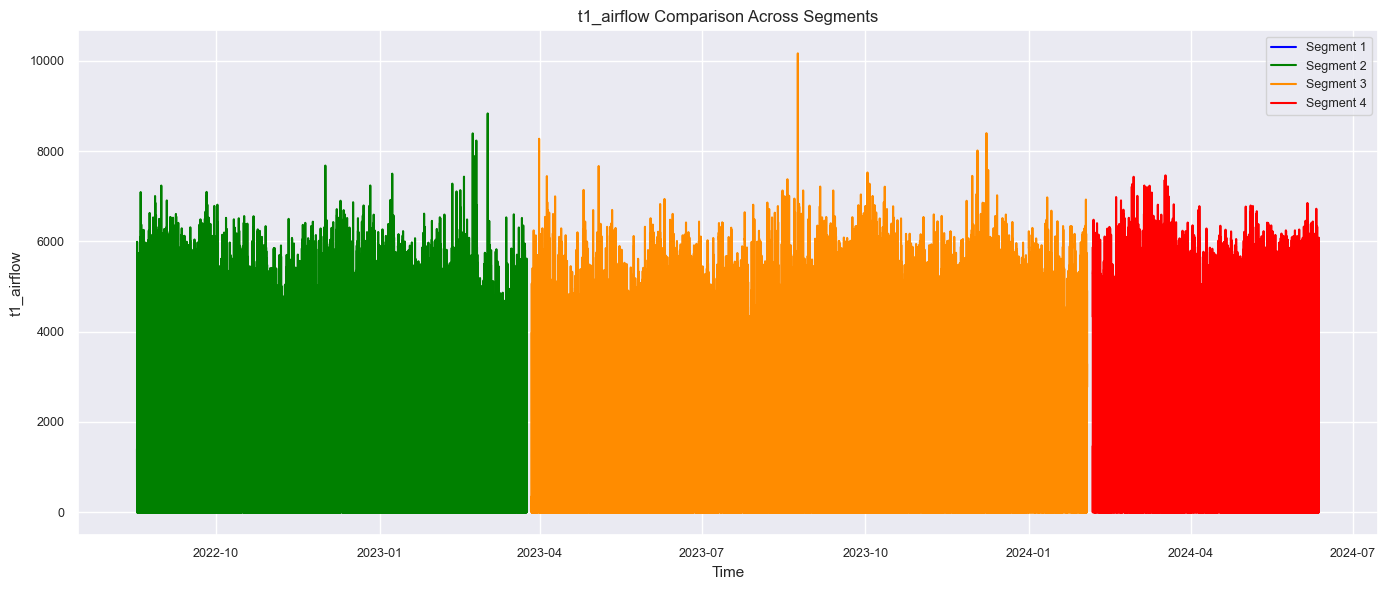

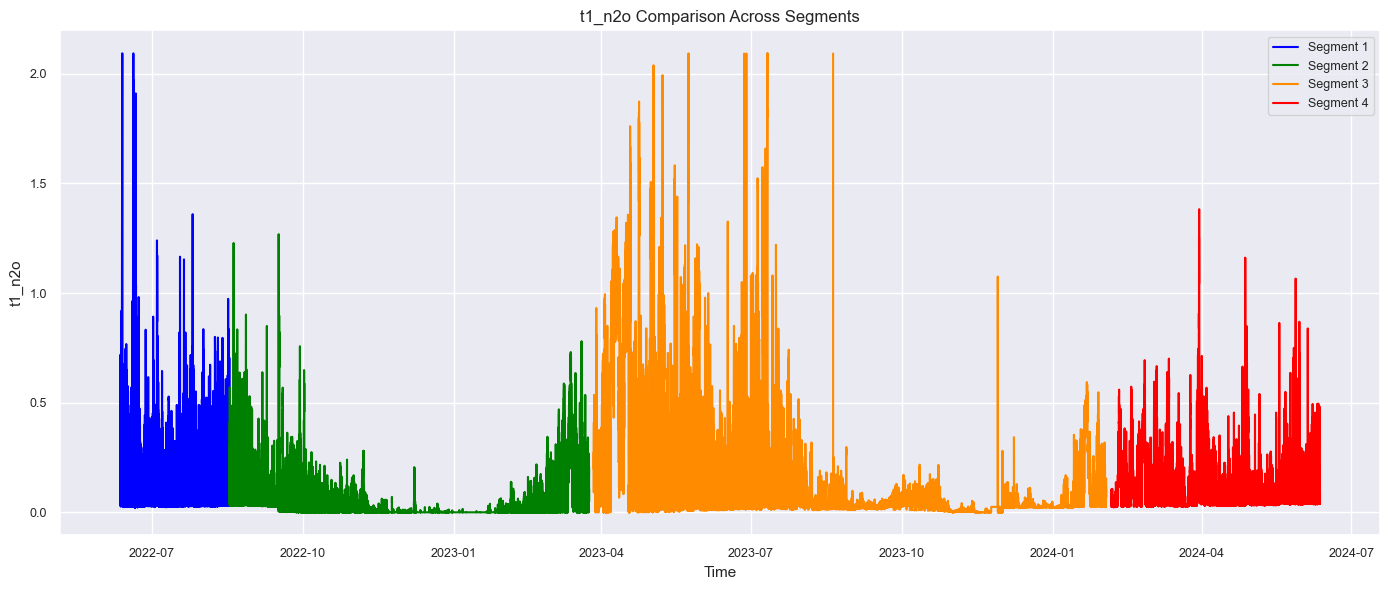

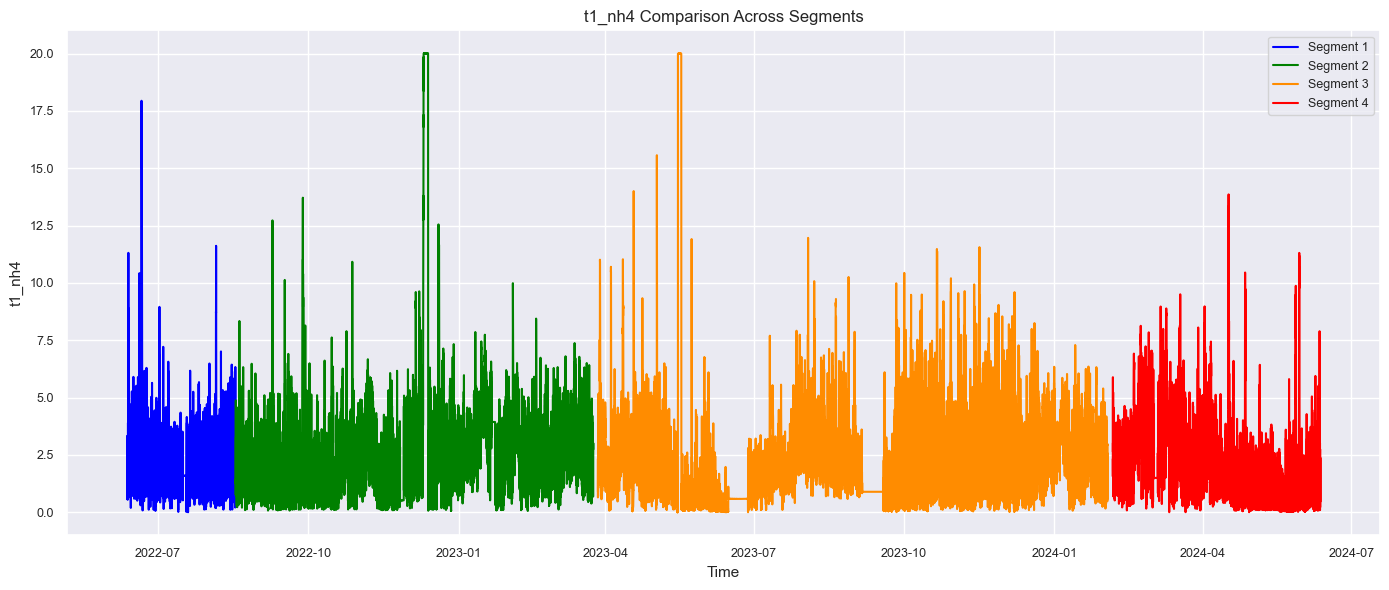

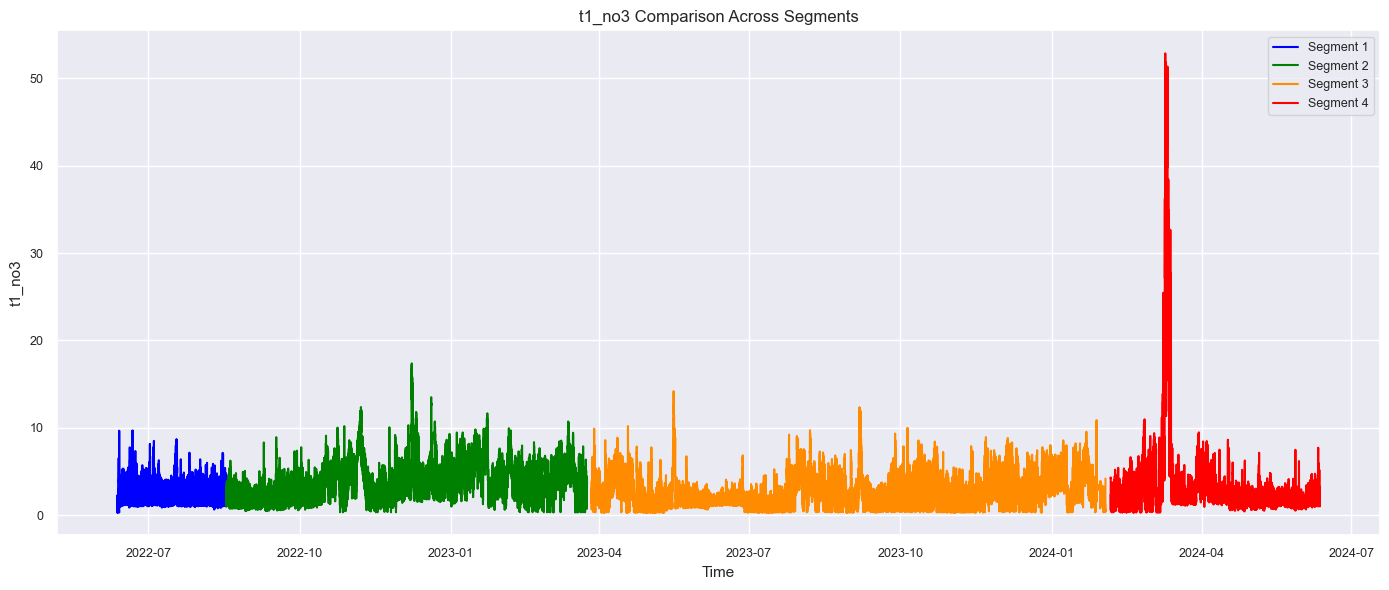

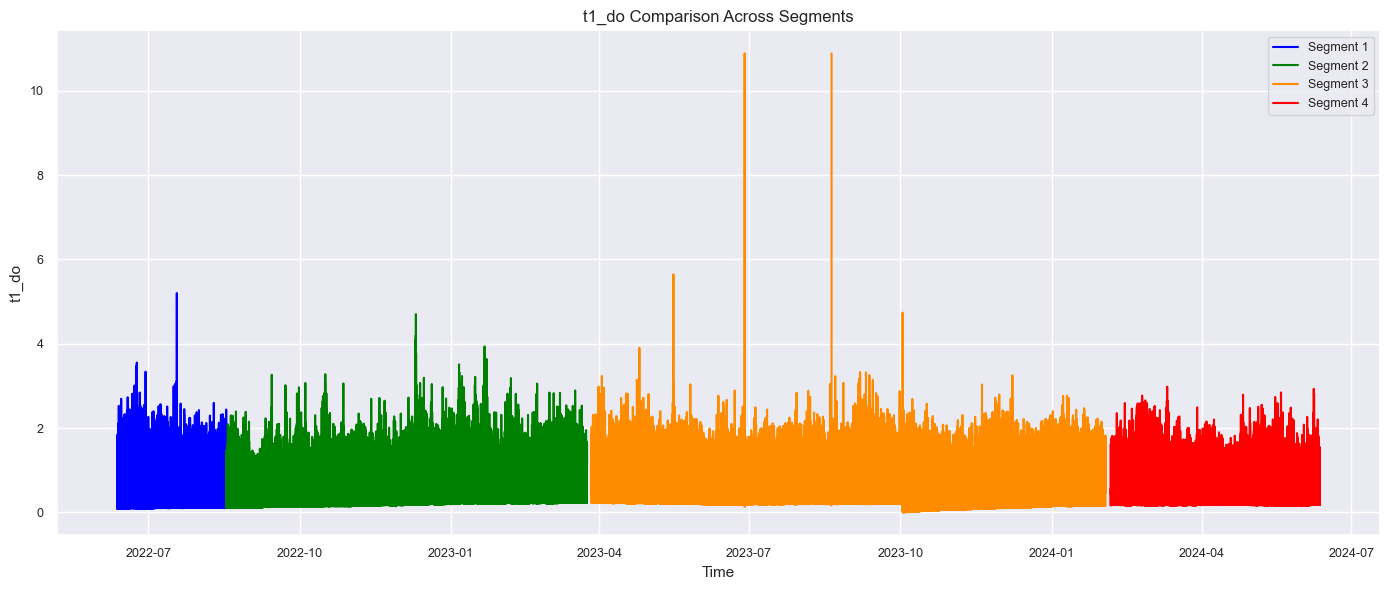

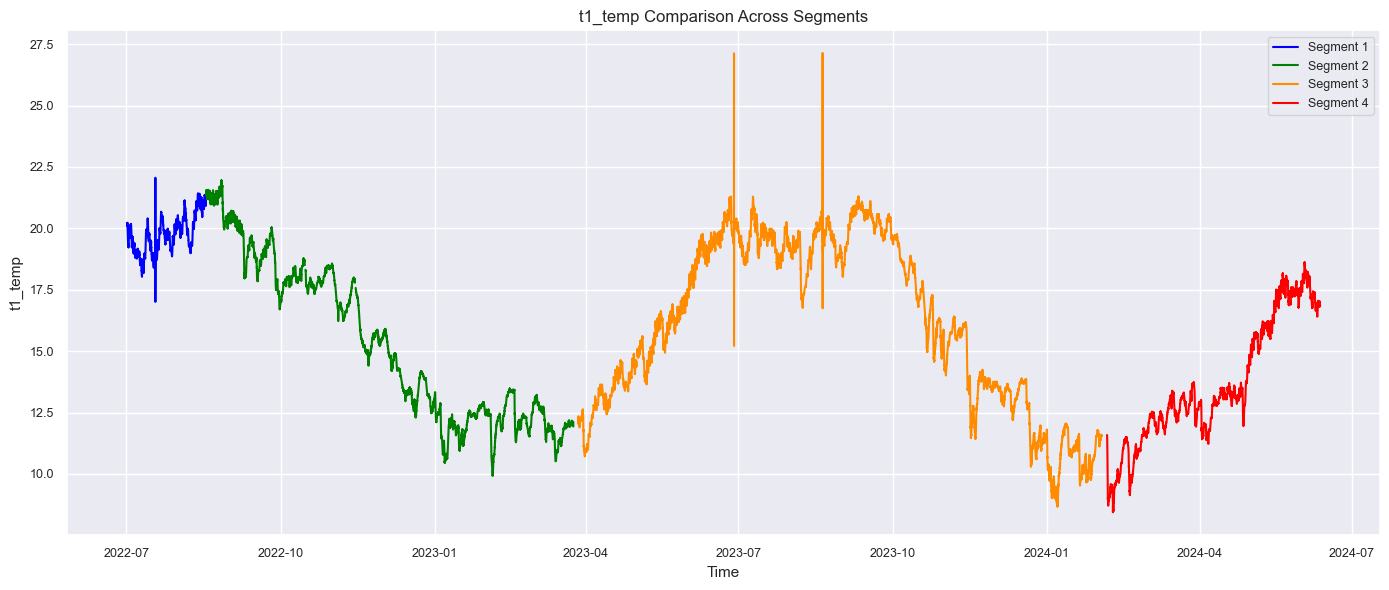

In [59]:
plot_segments_overlay(df_seg, cols_gaps)

##### N2O timeseries - variations in N2O emissions across segments

In [60]:
# Plot target variable across segments 

#Define function to plot n2o 
def plot_n2o_segments(df_seg):

    segment_ids = sorted(df_seg["segment_id"].unique())

    plt.figure(figsize=(14,6))

    for seg_id in segment_ids:

        seg_df = df_seg[df_seg["segment_id"] == seg_id]

        plt.plot(
            seg_df.index,
            seg_df["t1_n2o"],
            label=f"Segment {seg_id}",
            color=segment_colors.get(seg_id, "black")
        )

    plt.title("t1_n2o Across Segments")
    plt.xlabel("Time")
    plt.ylabel("t1_n2o")

    plt.legend()
    plt.tight_layout()
    plt.show()

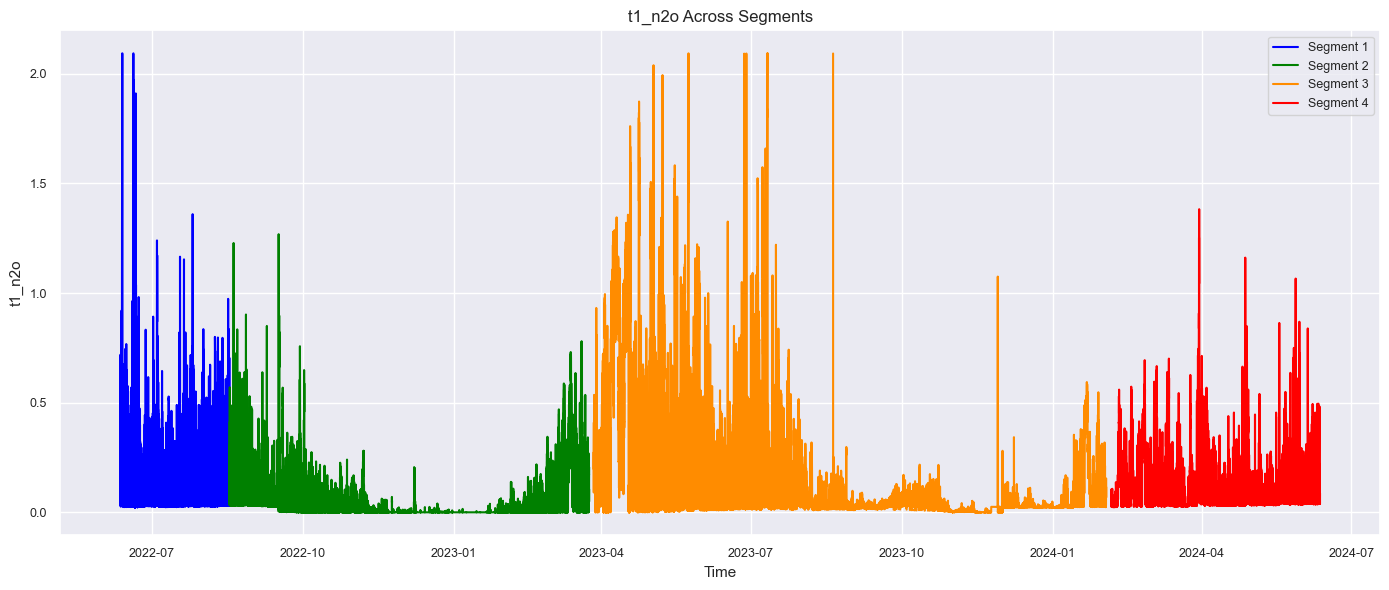

In [61]:
plot_n2o_segments(df_seg)

**Note on n2o distribution:** 
Review literature on seasonal fluctuations. 
- In general, the baseline for n2o emissions is around zero, with sustained periods above zero during specific time periods. 
- Values above zero could indicate periods of sustained, higher emissions - what variables affect this (i.e., is it seasonal?)

#### Rolling variability across segments (2-hour, 4-hour rolling std)

In [ ]:
#Define function to identify short-term fluctuations in n2o emissions 
def plot_n2o_rolling_variability(df_seg):

    df_seg = df_seg.sort_index()
    segment_ids = sorted(df_seg["segment_id"].unique())

    window_2h = 12
    window_4h = 24

    for seg_id in segment_ids:

        seg_df = df_seg[df_seg["segment_id"] == seg_id]

        # 2-hour rolling variability
        rolling_std_2h = seg_df["t1_n2o"].rolling(
            window=window_2h,
            min_periods=1
        ).std()

        plt.figure(figsize=(14,5))
        plt.plot(
            seg_df.index,
            rolling_std_2h,
            color=segment_colors.get(seg_id, "black")
        )

        plt.title(f"Segment {seg_id} – 2-Hour Rolling Std of N2O")
        plt.xlabel("Time")
        plt.ylabel("Rolling Std (2h)")
        plt.tight_layout()
        plt.show()

        # 4-hour rolling variability
        rolling_std_4h = seg_df["t1_n2o"].rolling(
            window=window_4h,
            min_periods=1
        ).std()

        plt.figure(figsize=(14,5))
        plt.plot(
            seg_df.index,
            rolling_std_4h,
            color=segment_colors.get(seg_id, "black")
        )

        plt.title(f"Segment {seg_id} – 4-Hour Rolling Std of N2O")
        plt.xlabel("Time")
        plt.ylabel("Rolling Std (4h)")
        plt.tight_layout()
        plt.show()

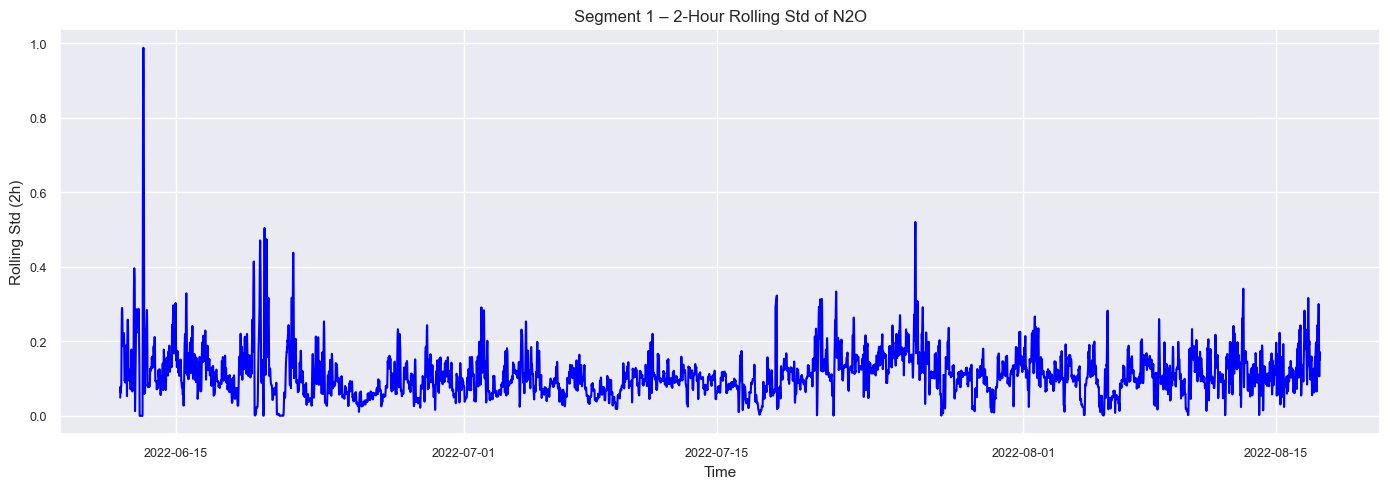

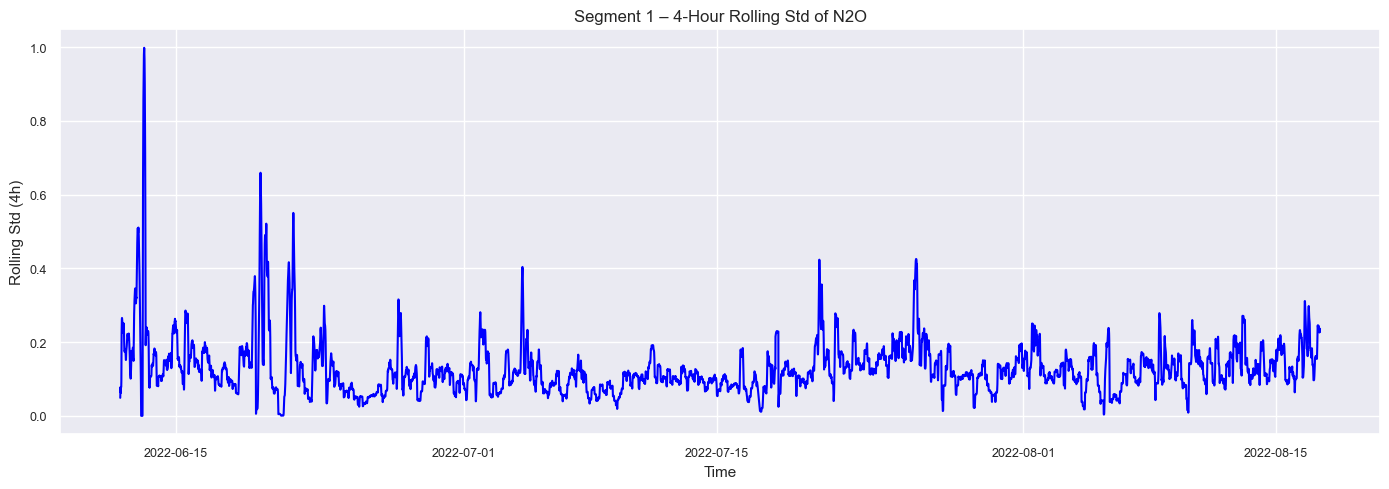

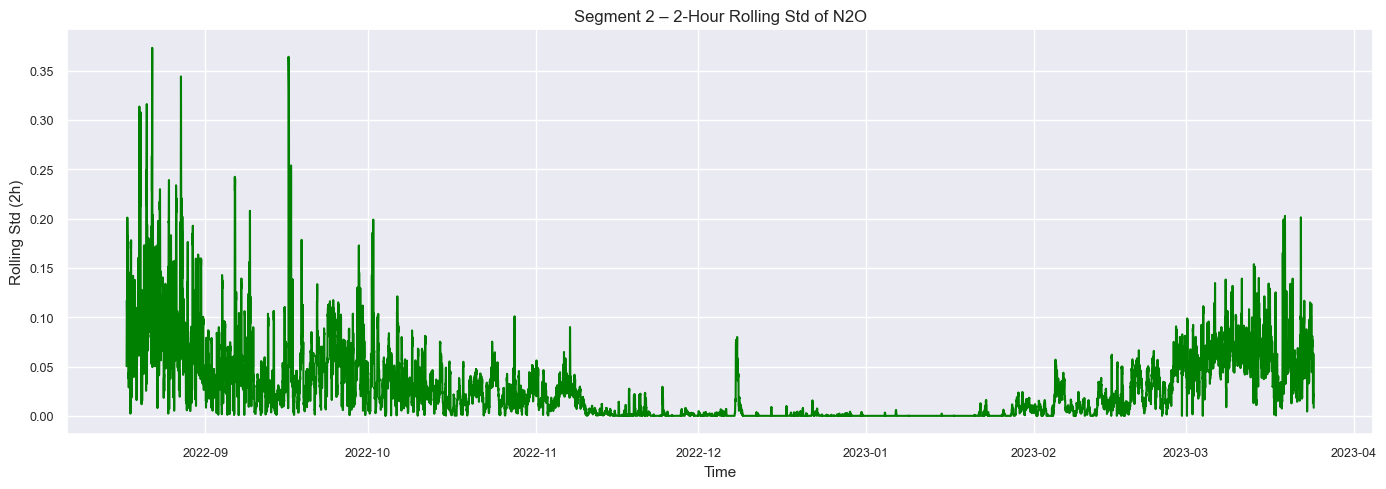

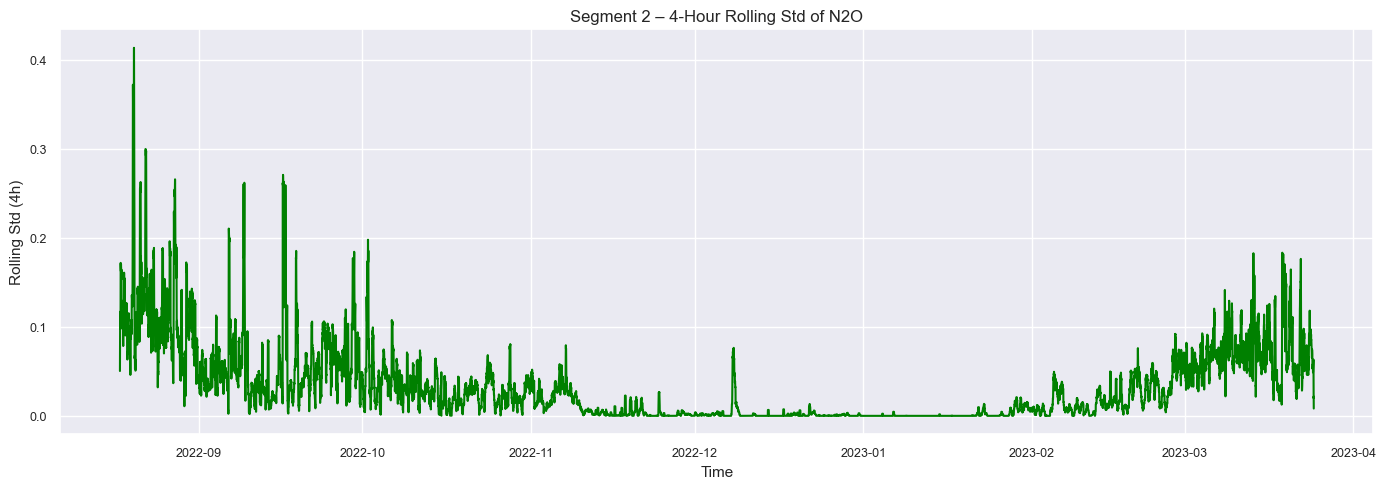

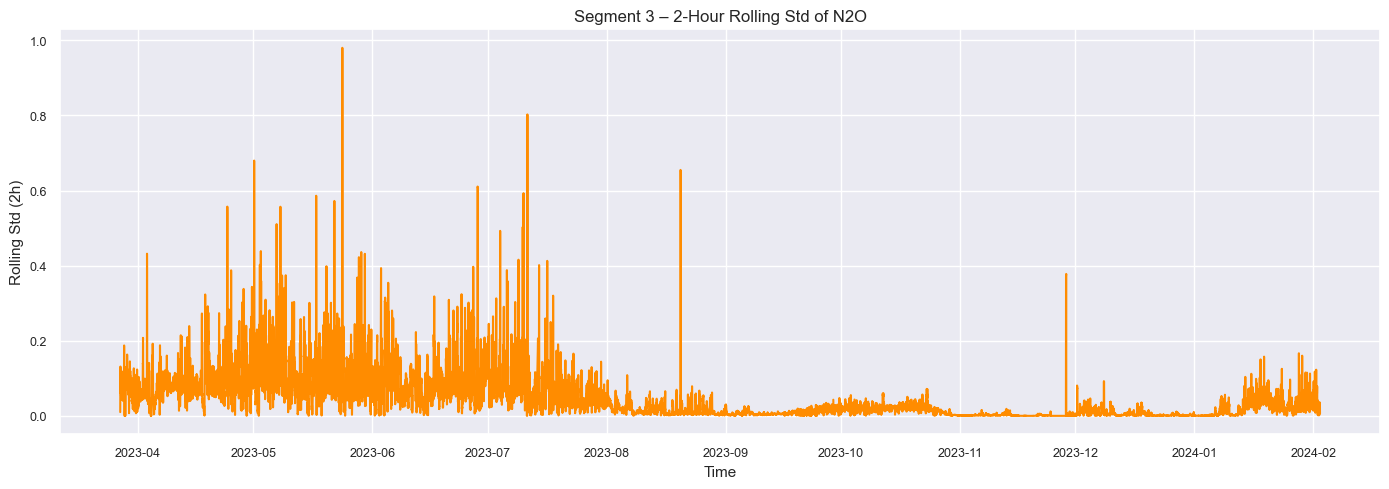

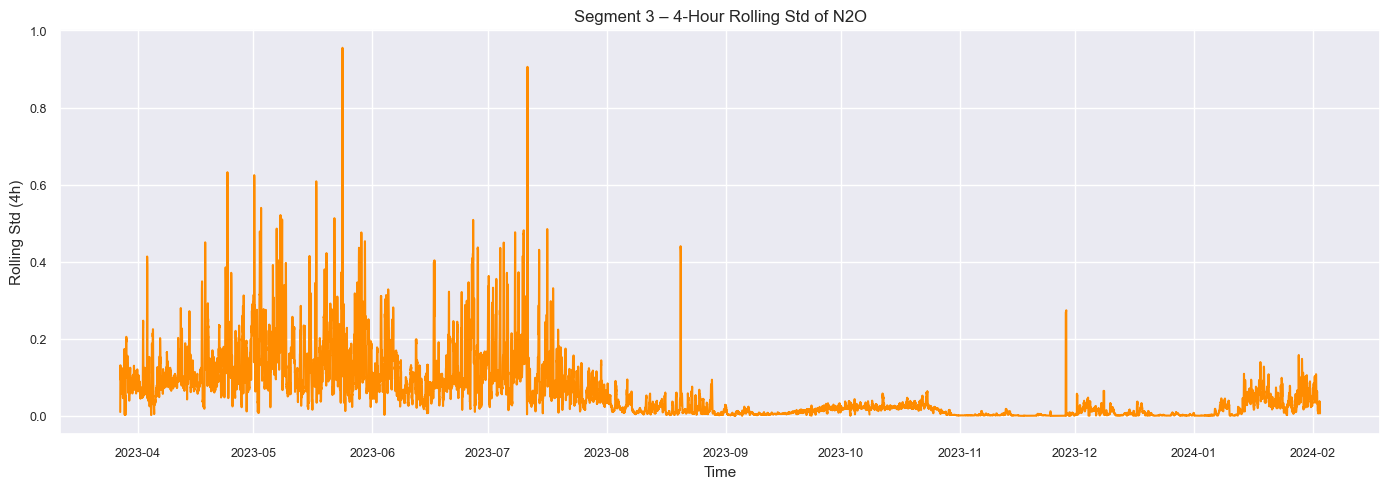

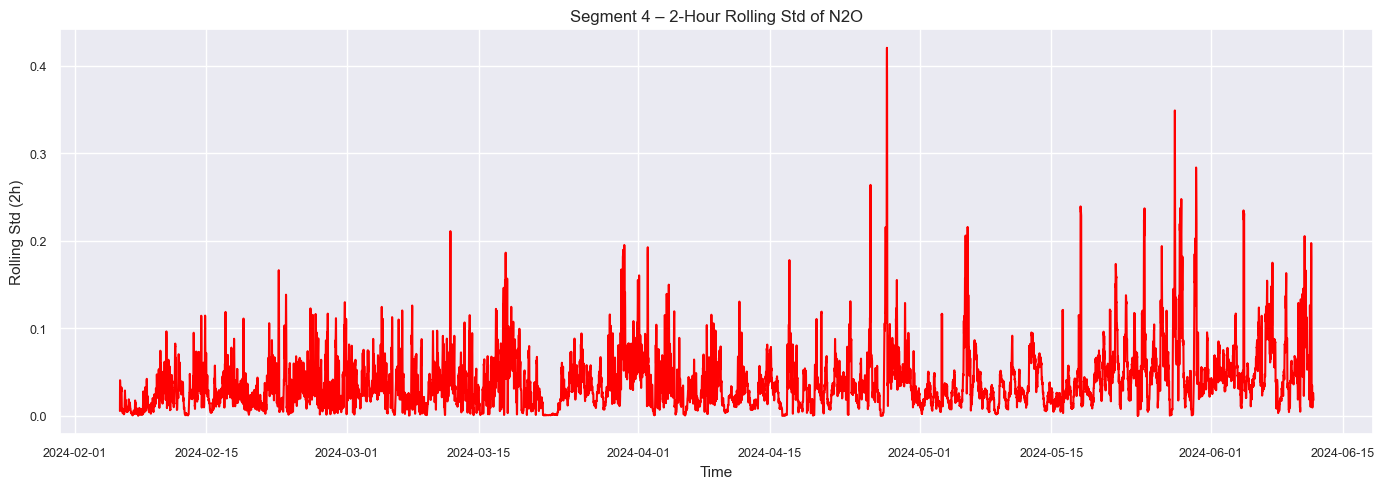

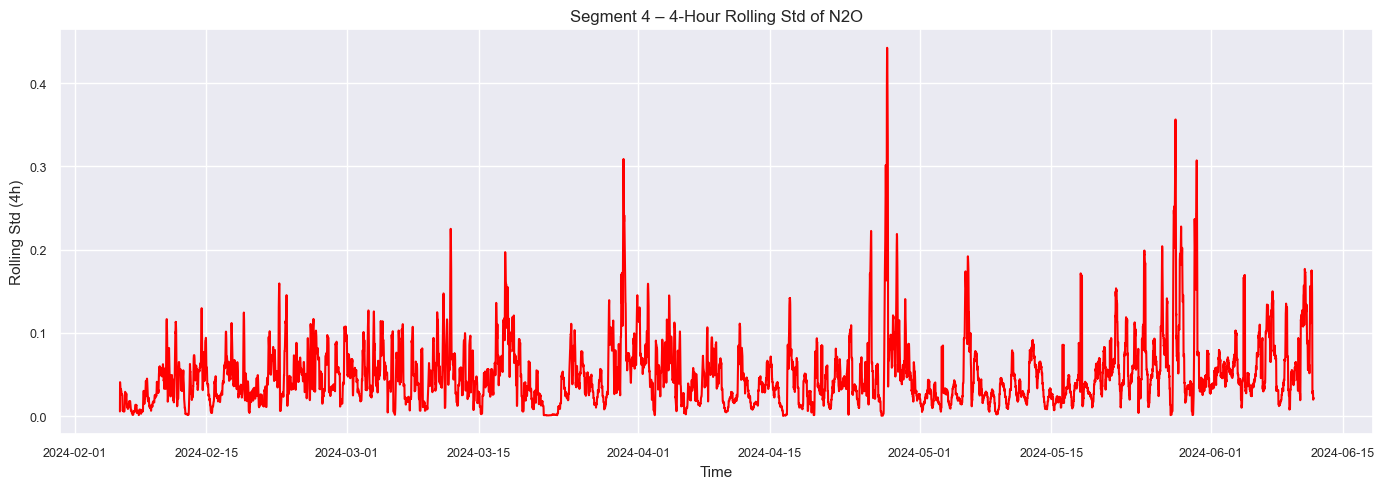

In [63]:
plot_n2o_rolling_variability(df_seg)

#### Descriptive Statistics Summary - All Segments

In [71]:
def n2o_variability_summary(df_seg):

    summary = []

    for seg_id in sorted(df_seg["segment_id"].unique()):

        seg_df = df_seg[df_seg["segment_id"] == seg_id]

        summary.append({
            "segment_id": seg_id,
            "duration_days": ((seg_df.index.max() - seg_df.index.min()).total_seconds() / 86400),
            "mean_n2o": seg_df["t1_n2o"].mean(),
            "std_n2o": seg_df["t1_n2o"].std(),
            "p95_n2o": seg_df["t1_n2o"].quantile(0.95),
            "p99_n2o": seg_df["t1_n2o"].quantile(0.99)
        })

    summary_df = (
        pd.DataFrame(summary)
        .sort_values("segment_id")
        .reset_index(drop=True)
    )

    return summary_df.round(4)

In [ ]:
n2o_variability_summary(df_seg)

,segment_id,duration_days,mean_n2o,std_n2o,p95_n2o,p99_n2o
0,1,66.5347,0.2052,0.2609,0.6087,1.5098
1,2,221.8611,0.0481,0.1036,0.2520,0.5377
2,3,315.4514,0.1685,0.2837,0.8395,1.2599
3,4,127.1250,0.1308,0.1474,0.4566,0.6612


#### Months covered by each segment 

In [81]:
#Define function to summarize the months covered by each segment 
def segment_month_summary(df_seg):

    df_temp = df_seg.copy()

    # extract year-month
    df_temp["year_month"] = df_temp.index.to_period("M")

    summary = (
        df_temp.groupby("segment_id")["year_month"]
        .unique()
        .apply(lambda x: ", ".join(str(m) for m in sorted(x)))
        .reset_index()
    )

    summary.columns = ["segment_id", "months_covered"]

    return summary

In [74]:
segment_month_summary(df_seg)

,segment_id,months_covered
0,1,"2022-06, 2022-07, 2022-08"
1,2,"2022-08, 2022-09, 2022-10, 2022-11, 2022-12, 2..."
2,3,"2023-03, 2023-04, 2023-05, 2023-06, 2023-07, 2..."
3,4,"2024-02, 2024-03, 2024-04, 2024-05, 2024-06"


In [79]:
#Define function to count number of rows in each month for each segment (data coverage summary)

def segment_month_counts(df_seg):

    df_temp = df_seg.copy()

    df_temp["year_month"] = df_temp.index.to_period("M")

    summary = (
        df_temp.groupby(["segment_id", "year_month"])
        .size()
        .unstack(fill_value=0)
    )

    return summary

In [ ]:
segment_month_counts(df_seg)

year_month,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06
segment_id,,,,,,,,,,,,,,,,,,,,,,,,,
1,2748,4464,2370,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,2094,4320,4464,4320,4464,4464,4032,3791,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,673,4320,4464,4320,4464,4464,4320,4464,4320,4464,4464,689,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3487,4464,4320,4464,1572


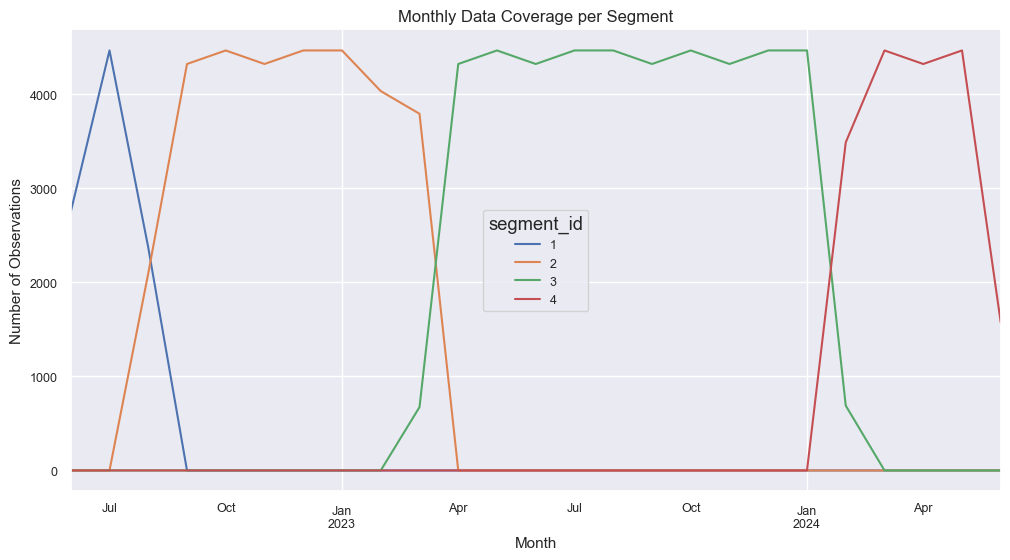

In [83]:
#Plot the monthly data coverage for each segment using the segment_month_counts function
segment_month_counts(df_seg).T.plot(figsize=(12,6))
plt.title("Monthly Data Coverage per Segment")
plt.ylabel("Number of Observations")
plt.xlabel("Month")
plt.show()

## 4 - Local EDA 

EDA for segments 2 and 3 which will be used for feature selection. 

In [53]:
#Define function to plot time series of key variables for a given segment dataframe and segment ID
def plot_segment(df_seg, segment_id, variables):

    seg_df = df_seg[df_seg["segment_id"] == segment_id]

    # get color assigned to this segment
    seg_color = segment_colors.get(segment_id, "black")

    for col in variables:

        plt.figure(figsize=(14,4))

        plt.plot(
            seg_df.index,
            seg_df[col],
            color=seg_color,
            label=f"Segment {segment_id}"
        )

        plt.title(f"Segment {segment_id} – {col}")
        plt.xlabel("Time")
        plt.ylabel(col)

        plt.legend()
        plt.tight_layout()
        plt.show()

### 4.1 - Plots of Key Features

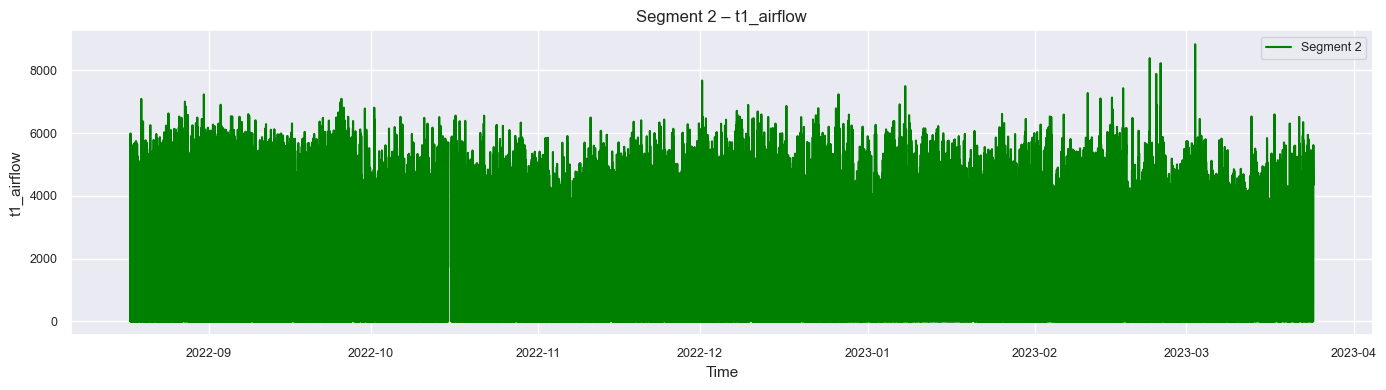

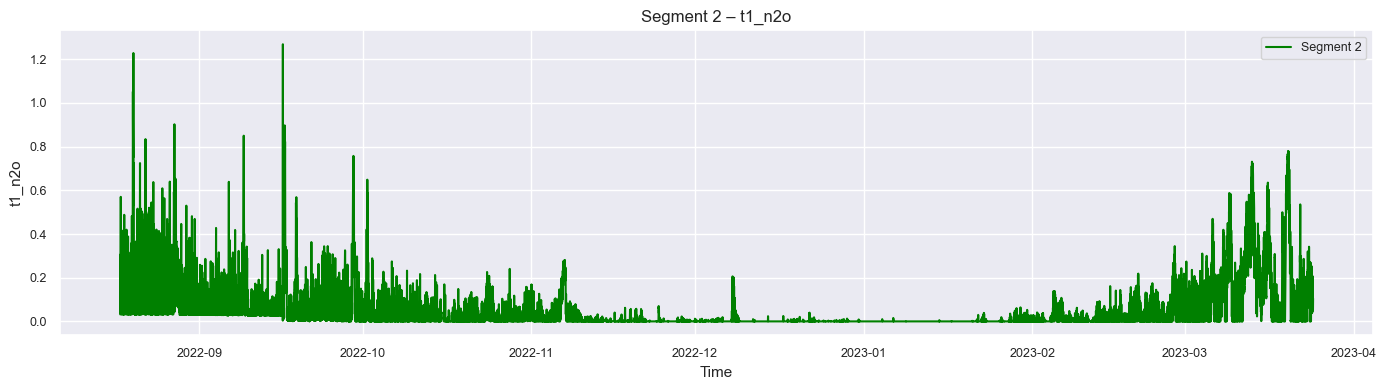

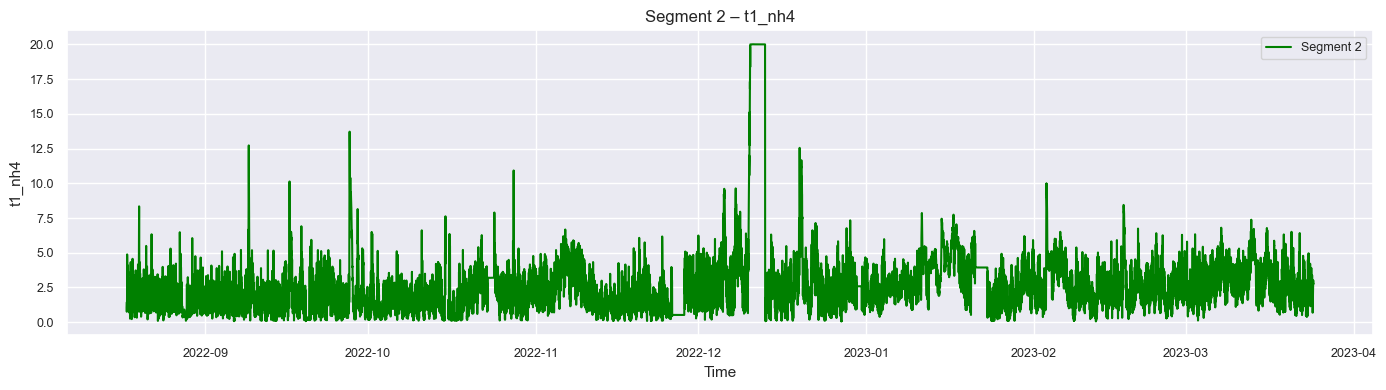

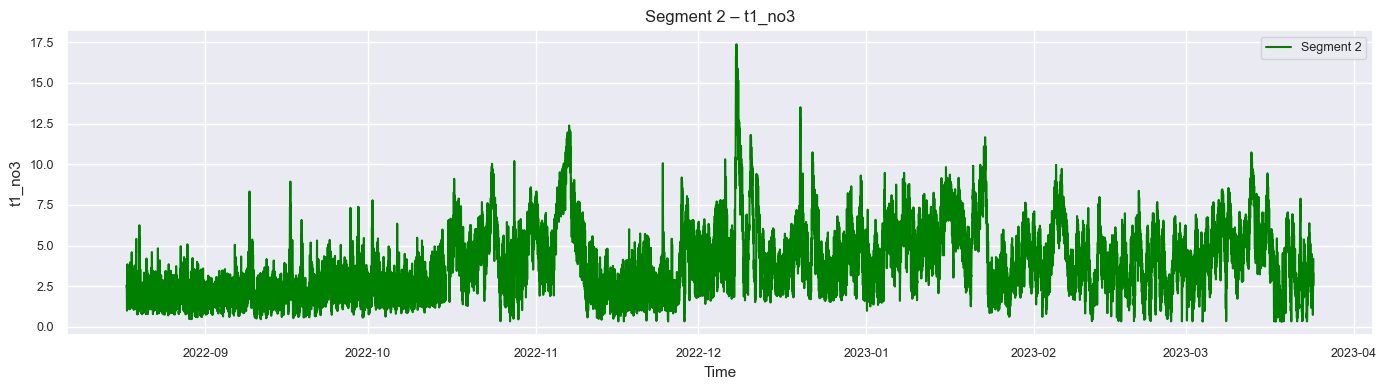

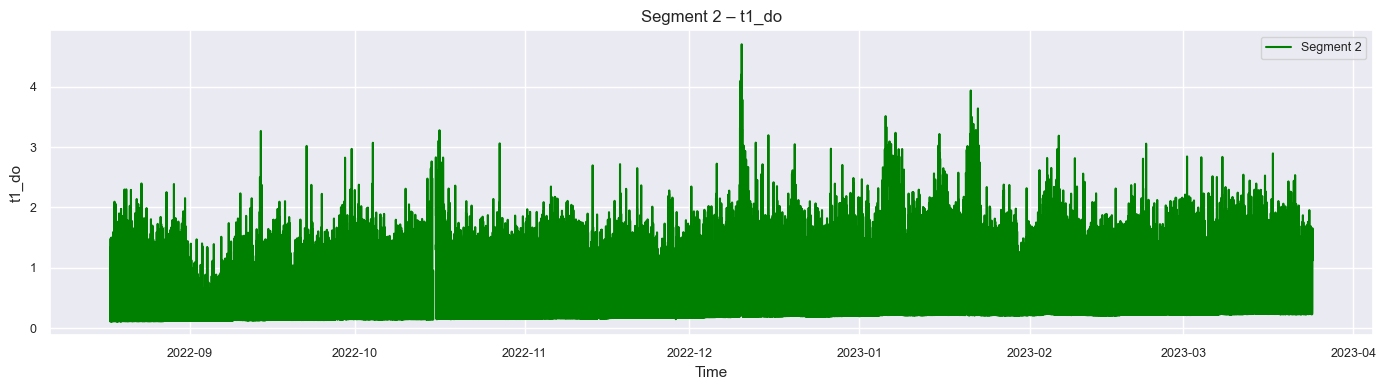

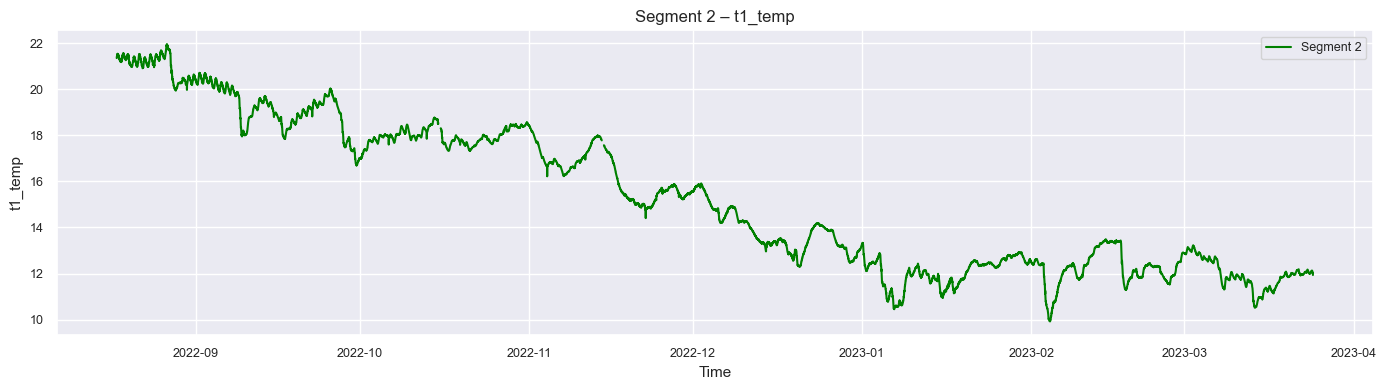

In [52]:
#Plot individual timeseries for segment 2 

plot_segment(df_seg, segment_id=2, variables=cols_gaps)

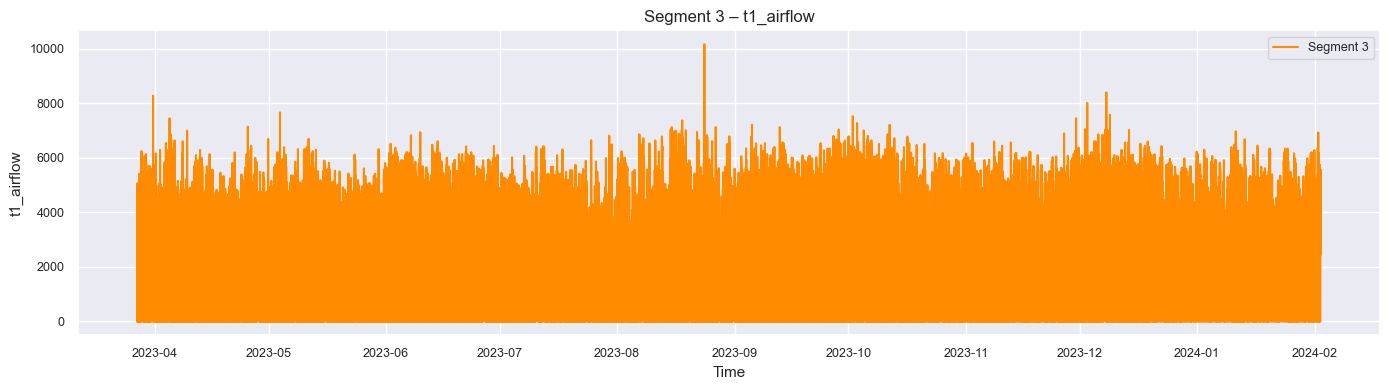

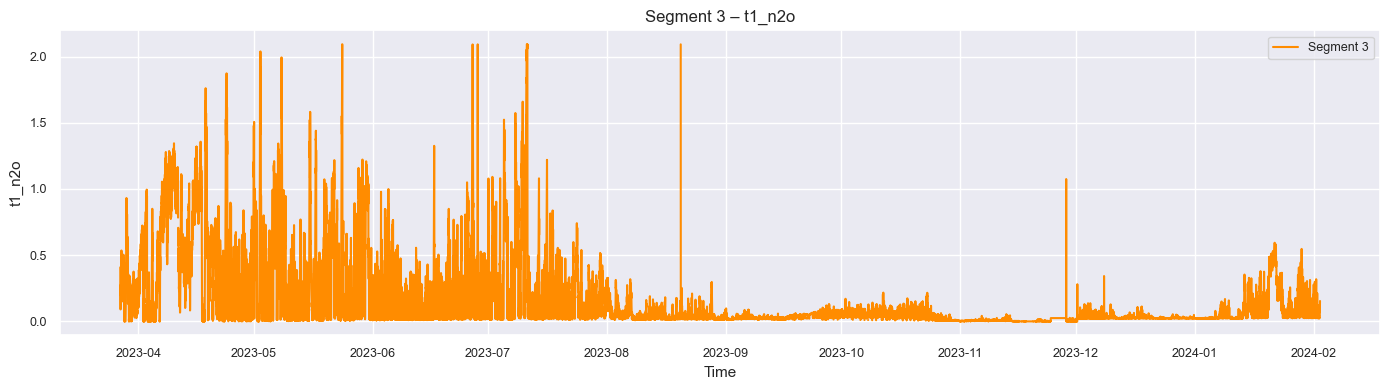

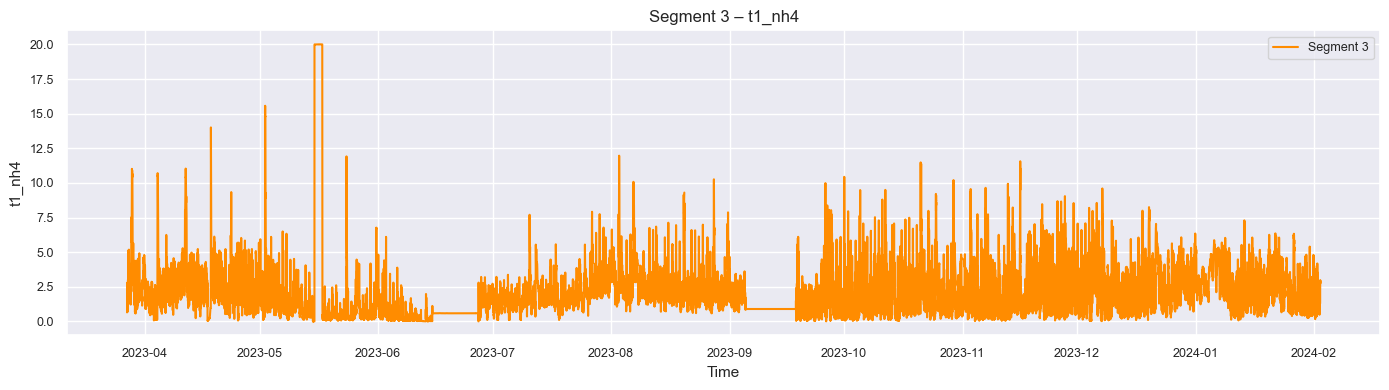

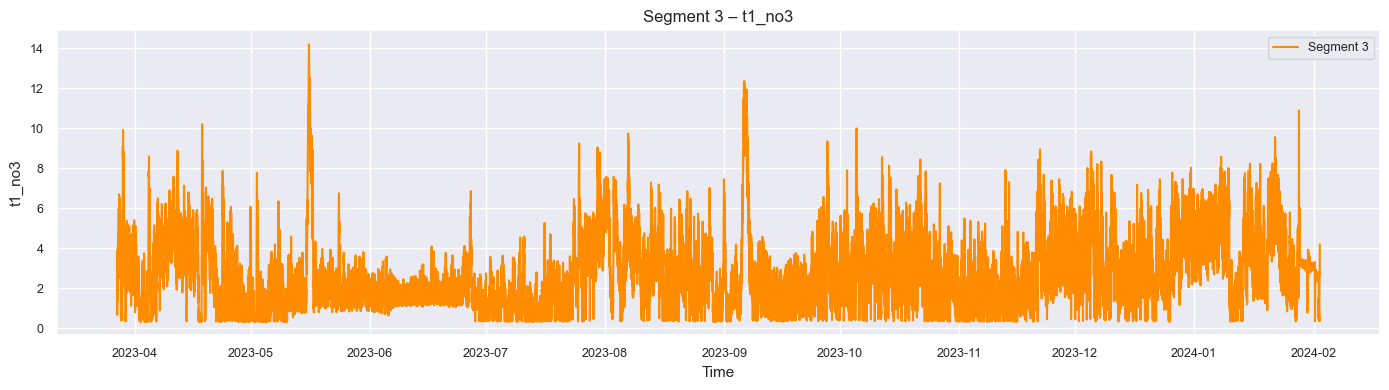

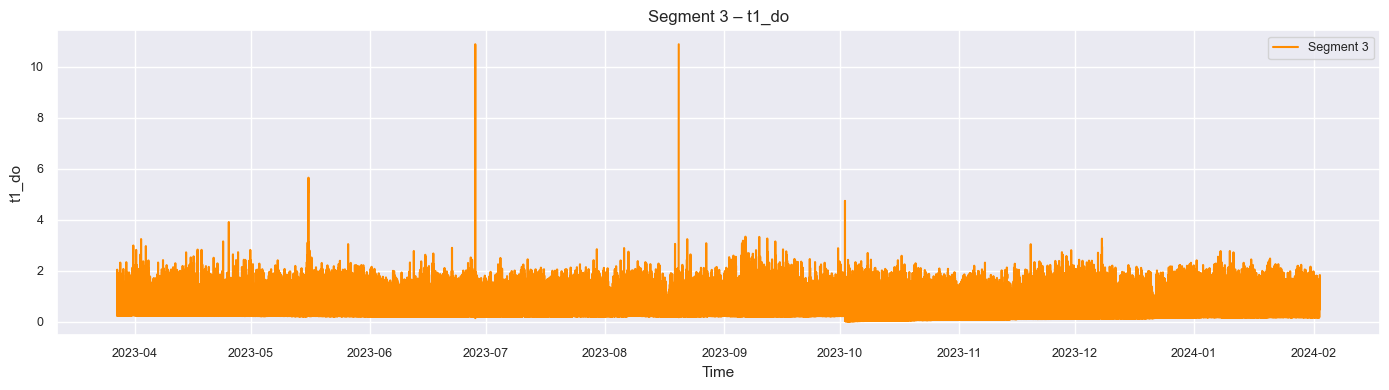

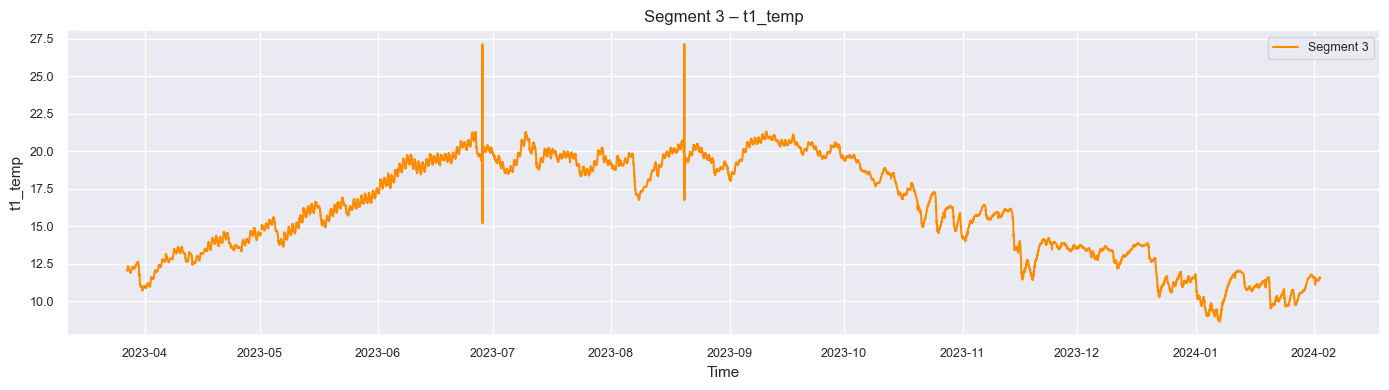

In [54]:
#Plot individual variables for segment 3

plot_segment(df_seg, segment_id=3, variables=cols_gaps)

## 5 - Interpolation

### 5.1 - Analysis of Missing Data in Segments 2 & 3

In [91]:
#Define function to summarize data gaps within each segment for specified columns and frequency

def gap_summary_by_segment(df_seg, cols, freq_minutes=10, segments=[2,3]):

    results = {}

    for seg_id in segments:

        df_s = df_seg[df_seg["segment_id"] == seg_id].sort_index()

        valid_mask = df_s[cols].notna().all(axis=1)
        gap_mask = ~valid_mask

        block_id = (gap_mask != gap_mask.shift()).cumsum()

        gap_blocks = (
            df_s.assign(gap=gap_mask, block=block_id)
                .groupby("block")
                .agg(
                    is_gap=("gap", "first"),
                    length_rows=("gap", "size")
                )
        )

        gap_blocks = gap_blocks[gap_blocks["is_gap"]]

        gap_blocks["duration_minutes"] = gap_blocks["length_rows"] * freq_minutes
        gap_blocks["duration_hours"] = gap_blocks["duration_minutes"] / 60

        results[f"Segment {seg_id}"] = {
            "10 min": (gap_blocks["duration_minutes"] == 10).sum(),
            "≤20 min": (gap_blocks["duration_minutes"] <= 20).sum(),
            "≤1 hour": (gap_blocks["duration_minutes"] <= 60).sum(),
            "1–4 hours": ((gap_blocks["duration_hours"] > 1) &
                          (gap_blocks["duration_hours"] <= 4)).sum(),
            ">4 hours": (gap_blocks["duration_hours"] > 4).sum(),
            ">6 hours": (gap_blocks["duration_hours"] > 6).sum(),
            ">8 hours": (gap_blocks["duration_hours"] > 8).sum(),
        }

    summary = pd.DataFrame(results)

    return summary

In [92]:
gap_summary = gap_summary_by_segment(
    df_seg,
    cols_gaps,
    freq_minutes=10,
    segments=[2,3]
)

gap_summary

,Segment 2,Segment 3
10 min,43,349
≤20 min,59,532
≤1 hour,66,782
1–4 hours,4,40
>4 hours,3,3
>6 hours,3,1
>8 hours,3,1


In [97]:
#Histogram to visualize gap durations in segment 2 and segment 3

def get_gap_durations(df_seg, cols, segment_id, freq_minutes=10):

    df_s = df_seg[df_seg["segment_id"] == segment_id].sort_index()

    valid_mask = df_s[cols].notna().all(axis=1)
    gap_mask = ~valid_mask

    block_id = (gap_mask != gap_mask.shift()).cumsum()

    gap_blocks = (
        df_s.assign(gap=gap_mask, block=block_id)
            .groupby("block")
            .agg(
                is_gap=("gap", "first"),
                length_rows=("gap", "size")
            )
    )

    gap_blocks = gap_blocks[gap_blocks["is_gap"]]

    gap_blocks["duration_minutes"] = gap_blocks["length_rows"] * freq_minutes

    return gap_blocks["duration_minutes"]

In [98]:
def plot_gap_bins(df_seg, cols, segment_id):

    durations = get_gap_durations(df_seg, cols, segment_id)

    bins = [
        ("10 min", durations == 10),
        ("≤20 min", durations <= 20),
        ("≤1 hour", durations <= 60),
        ("1–4 hours", (durations > 60) & (durations <= 240)),
        (">4 hours", durations > 240),
        (">6 hours", durations > 360),
        (">8 hours", durations > 480)
    ]

    labels = []
    counts = []

    for label, condition in bins:
        labels.append(label)
        counts.append(condition.sum())

    plt.figure(figsize=(8,5))

    plt.bar(
        labels,
        counts,
        color=segment_colors.get(segment_id, "black")
    )

    plt.title(f"Gap Size Categories – Segment {segment_id}")
    plt.xlabel("Gap Duration Category")
    plt.ylabel("Frequency")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

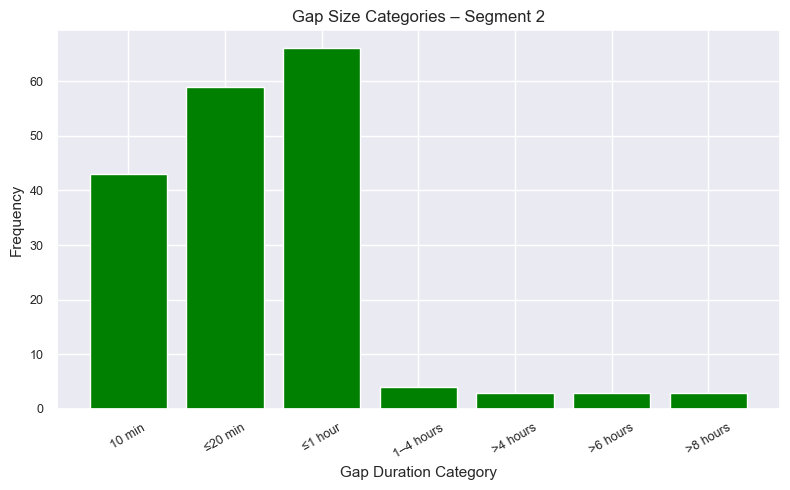

In [99]:
plot_gap_bins(df_seg, cols_gaps, segment_id=2)

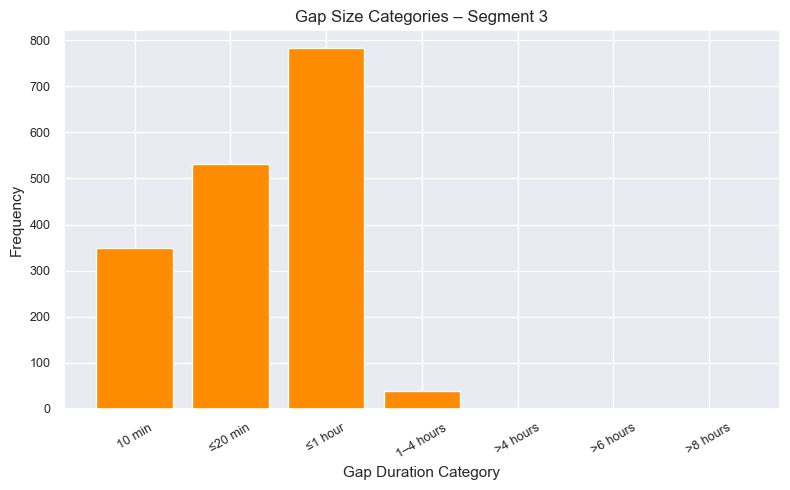

In [ ]:
plot_gap_bins(df_seg, cols_gaps, segment_id=3)

In [101]:
def plot_gap_comparison(df_seg, cols, segments=[2,3], freq_minutes=10):

    gap_categories = [
        "10 min",
        "≤20 min",
        "≤1 hour",
        "1–4 hours",
        ">4 hours",
        ">6 hours",
        ">8 hours"
    ]

    segment_counts = {}

    for seg_id in segments:

        durations = get_gap_durations(df_seg, cols, seg_id, freq_minutes)

        counts = [
            (durations == 10).sum(),
            (durations <= 20).sum(),
            (durations <= 60).sum(),
            ((durations > 60) & (durations <= 240)).sum(),
            (durations > 240).sum(),
            (durations > 360).sum(),
            (durations > 480).sum()
        ]

        segment_counts[f"Segment {seg_id}"] = counts

    df_plot = pd.DataFrame(segment_counts, index=gap_categories)

    ax = df_plot.plot(
        kind="bar",
        figsize=(10,6),
        color=[segment_colors.get(2, "blue"),
               segment_colors.get(3, "orange")]
    )

    ax.set_title("Gap Duration Comparison: Segment 2 vs Segment 3")
    ax.set_xlabel("Gap Duration Category")
    ax.set_ylabel("Number of Gaps")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

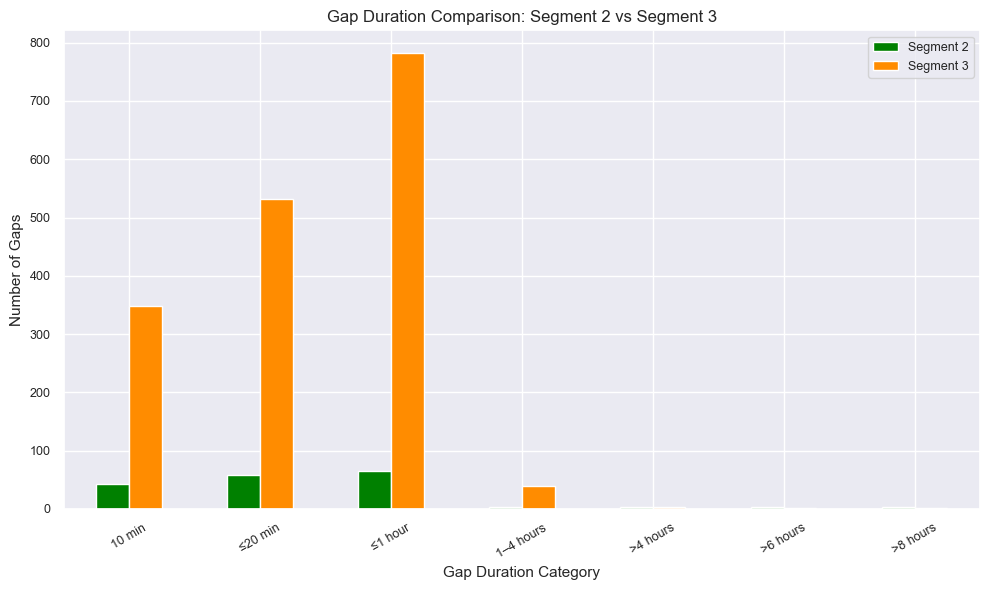

In [102]:
plot_gap_comparison(df_seg, cols_gaps)

### 5.3 - Save updated dataframes -> csv

## Additional notes

#### Kolmogorov-Smirnov (KS) test 
Non-parametric method for comparing the probability distributions of two samples. Does not assume a specific distribution. The KS test compares the empirical cumulative distribution functions (ECDFs) of two samples; the KS statistic calculates the maximum vertical distance between the two cumulative distributions. 

The KS test is appropriate for our dataset since the variables don't have normal distributions, are skewed (see preprocessing notebook) and contain rare extreme values / spikes.

The test is used to compare the distribution of the raw vs. resampled dataset to determine if resampling changes the underlying data distribution. 